# 01 - PTB-XL exploratory data analysis

PTB-XL is a public collection of 21,799 clinical twelve-lead ECGs from 18,869 patients, recorded in
Germany between 1984 and 2001 and annotated by cardiologists with SCP-ECG statements. This notebook
describes the dataset itself: what is recorded, what is missing or wrong, how diagnoses relate to age
and sex, and what the waveforms look like.

Everything is computed from the raw PTB-XL 1.0.3 release (`data/raw/ptb-xl/1.0.3/`). The analysis code
lives in `ecg_experiment/eda/` as plain Python; this notebook calls it and explains the results.

**How to read it.** Each section starts with the question, shows the evidence and ends with a short
*Finding*. The conclusions are collected at the end.

**Context of this delivery.** The project's own database, from Italy, is not available yet, so this first
delivery runs the full exploratory analysis on PTB-XL, the public dataset closest to it (cardiologist-read
twelve-lead ECGs). The same steps will be repeated on the project's data when it arrives.

| Guiding question | Section |
| --- | --- |
| Variable types: categorical, nominal, ordinal and quantitative | 1 |
| Missing values and their patterns | 3 |
| Summary statistics | 2, 5 |
| Outliers | 4, 5, 11 |
| Cardinality of categorical variables | 2, 7, 9 |
| Skewed distributions and transformations | 5 |
| Temporal trends | 6 |
| Correlation between the target and the other variables | 10 |
| Distributions across categories (bivariate) | 6, 10, 12 |
| Normalizing the signals for display | 13 |
| Class imbalance in the target | 8 |

The answers are collected in section 15.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.ticker import MaxNLocator
from scipy.stats import mannwhitneyu

from ecg_experiment.eda.profile import (
    column_profile,
    cramers_v_matrix,
    frequencies,
    log_skew,
    missing_correlation,
    numeric_summary,
    remove_baseline,
    standardize_leads,
)
from ecg_experiment.eda.ptbxl import (
    OUTPUT_DIR,
    SUPERCLASSES,
    diagnostic_classes,
    implausible_rows,
    load_metadata,
    load_statements,
    project_label,
    read_signal,
    superclass_flags,
    superclasses,
)
from ecg_experiment.eda.ptbxl_cleaning import SCALES, clean_metadata
from ecg_experiment.eda.ptbxl_signals import (
    annotation_agreement,
    lead_features,
    low_rate_consistency,
    ptbxl_summary,
)
from ecg_experiment.eda.signals import LEADS, plot_ecg, problem_counts
from ecg_experiment.eda.stats import age_band, association_test, odds_ratios, plot_prevalence, prevalence

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 100})

meta = load_metadata()
statements = load_statements()
classes = diagnostic_classes(statements)
meta = meta.join(superclass_flags(meta, classes))
meta["classes"] = meta["scp_codes"].apply(superclasses, classes=classes)
meta["male"] = meta["sex"].eq(0)
meta["sex_name"] = np.where(meta["male"], "male", "female")
meta["age_band"] = age_band(meta["age_capped"])
summary = ptbxl_summary(meta.drop(columns=["age_band"]))

## 1. Structure of the data

Shape, data types and measurement scale of every column of `ptbxl_database.csv`, then the basic counts:
recordings, patients, and the ten stratified folds the release defines. Several columns are stored as
numbers but are really codes (nurse, site, validator), so the scale column matters more than the dtype.

### What kind of variable is each one?

A variable is something recorded or calculated for an ECG. Its **meaning**, rather than its Python
storage type, determines how we should summarize it.

- **Categorical:** a label or group. **Nominal** categories have no natural order; **ordinal** categories
  have a meaningful order, but the distance between categories is not a measured quantity.
- **Quantitative:** a measured amount or a count. **Continuous** variables describe measurements;
  **discrete** variables count whole items. Rounding a measurement does not turn it into a category.

Nominal and ordinal are subtypes of categorical variables, not two extra groups alongside categorical
and quantitative. Quantitative scales can also be **ratio** (a meaningful zero, such as weight) or
**interval** (meaningful differences, such as recording dates).

| Variables in this notebook | Type | Why it matters |
| --- | --- | --- |
| `sex`, `sex_name`, `male`, `device`, `heart_axis`, `nurse`, `site`, `validated_by`, `strat_fold` | Categorical, nominal | Names or codes identify groups. Fold 10 is not a larger measured quantity than fold 1. |
| `scp_codes`, `classes`, superclass flags (`NORM`, `MI`, `STTC`, `CD`, `HYP`) | Categorical, nominal; multiple labels can coexist | Disease groups have no severity order. The numbers inside `scp_codes` are annotation likelihood codes, discussed in section 7, not disease categories or calibrated probabilities. |
| `abnormal`, `label`, `second_opinion`, `initial_autogenerated_report`, `validated_by_human`, quality and missingness flags | Categorical, nominal and binary | A stored 0/1 or boolean represents a category. Missing labels remain missing. |
| `infarction_stadium1`, `infarction_stadium2`, ordered `age_band` | Categorical, ordinal where the category has an order | Stages I, II and III have an order; the stage is not a measured severity score. `unknown` and missing values have no rank; combined stages such as I-II need explicit handling. Age bands are ordered ranges. |
| `age`, `age_capped`, `height`, `weight`, derived BMI, estimated `heart_rate` | Quantitative measurements, treated as continuous | Summarize with physical units. Age 300 is a placeholder for over 89, not a measured age. |
| `std`, `baseline_fraction`, `high_frequency_fraction`, `peak_abs_mv`, voltage samples and signal residual measures | Quantitative, continuous | These measure signal magnitude or power. Their names describe measurements, not diagnoses. |
| `statements`, recording/beat/sample counts and counts of affected leads | Quantitative, discrete | They count whole items; for example, two SCP statements per ECG. |
| `recording_date`, derived `year` | Temporal, quantitative interval scale (`year` is discrete) | Differences represent elapsed time; the calendar origin is arbitrary. |
| `ecg_id` (the row index), `patient_id`, `filename_lr`, `filename_hr` | Identifiers, nominal in meaning | Digits identify records or people. Their mean or numerical distance is not informative. |
| `report`, `baseline_drift`, `static_noise`, `burst_noise`, `electrodes_problems`, `extra_beats`, `pacemaker` | Free text or structured annotations | These are not measured quantities. Section 9 derives nominal presence flags from the annotation text. |
| Lead names such as I, II and V1-V6 | Categorical, nominal | They identify recording channels; numbering does not define an ordered severity scale. |

This table describes the metadata and derived measurements used here. An infarction-stage annotation
is an ordinal variable in the source data; it does not supply an ordinal severity outcome for the
separate localization algorithm.


In [3]:
raw = meta[list(SCALES)]
print(f"Rows: {raw.shape[0]:,}   columns: {raw.shape[1]}   memory: {raw.memory_usage(deep=True).sum() / 1e6:.0f} MB")
display(raw.dtypes.astype(str).value_counts().to_frame("columns"))
profile = column_profile(raw, SCALES)
display(profile.round(3))

Rows: 21,799   columns: 27   memory: 12 MB


,columns
str,13
float64,7
bool,3
int64,2
datetime64[us],1
object,1


,dtype,scale,non_null,missing_share,unique,example
column,,,,,,
patient_id,float64,identifier,21799,0.000,18869,15709.0
age,float64,ratio (300 = over 89),21799,0.000,89,56.0
sex,int64,"nominal, binary (0 male)",21799,0.000,2,1
height,float64,ratio (cm),6974,0.680,77,172.0
weight,float64,ratio (kg),9421,0.568,127,63.0
nurse,float64,"nominal, coded ID",20326,0.068,12,2.0
site,float64,"nominal, coded ID",21782,0.001,51,0.0
device,str,nominal,21799,0.000,11,CS-12 E
recording_date,datetime64[us],interval (date and time),21799,0.000,21795,1984-11-09 09:17:34


In [4]:
overview = pd.Series({
    "recordings": len(meta),
    "patients": meta["patient_id"].nunique(),
    "raw columns": raw.shape[1],
    "first recording": meta["recording_date"].min().date(),
    "last recording": meta["recording_date"].max().date(),
})
display(overview.to_frame("value"))
display(meta.groupby("strat_fold").agg(records=("patient_id", "size"),
                                       patients=("patient_id", "nunique"),
                                       human_validated=("validated_by_human", "mean")).T.round(2))
per_patient = meta.groupby("patient_id").size()
display(per_patient.value_counts().sort_index().to_frame("patients with this many ECGs").T)

,value
recordings,21799
patients,18869
raw columns,27
first recording,1984-11-09
last recording,2001-06-11


strat_fold,1,2,3,4,5,6,7,8,9,10
records,2175.00,2181.00,2192.00,2174.00,2174.00,2173.00,2176.00,2173.00,2183.0,2198.0
patients,1878.00,1849.00,1887.00,1883.00,1890.00,1884.00,1871.00,1881.00,1942.0,1904.0
human_validated,0.67,0.66,0.67,0.68,0.68,0.64,0.68,0.68,1.0,1.0


,1,2,3,4,5,6,7,8,9,10
patients with this many ECGs,16758,1590,350,99,43,16,5,4,3,1


**Finding.** The table has 21,799 rows and 27 columns: 13 text, 7 float, 3 boolean, 2 integer, one date and
one dictionary column (`scp_codes`). The dtype is misleading for four of the float columns: `patient_id` is
an identifier, and `nurse`, `site` and `validated_by` are coded IDs stored as floats only because they have
gaps. The only true numeric measurements in the metadata are age, height and weight; everything else is
categorical, free text or an identifier. The waveforms (12 leads x 5,000 samples per record) are described
from section 11 on.

21,799 ten-second recordings from 18,869 patients. 2,111 patients have more than one ECG
(up to 10), so records are not independent: any statistic or split should account for patients. The
ten folds are balanced in size, and each patient sits in exactly one fold. Folds 9 and 10 were fully
reviewed by a human cardiologist, against about two thirds of the other folds.

## 2. Descriptive statistics and cardinality

Summary statistics of the numeric columns, then the frequency of every class of the categorical columns
(missing values shown as their own class, the long tail summed into `(other)`), and finally the
cardinality of each non-identifier column.

In [5]:
display(numeric_summary(meta, ["age", "age_capped", "height", "weight"]).round(2))
categorical = ["sex_name", "device", "heart_axis", "infarction_stadium1", "infarction_stadium2", "nurse", "site",
               "validated_by", "strat_fold", "second_opinion", "initial_autogenerated_report", "validated_by_human"]
display(meta[categorical].astype(object).describe().T)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,outliers,outlier_share
age,21799.0,62.77,32.31,2.0,50.0,62.0,72.0,300.0,5.16,36.33,385,0.02
age_capped,21506.0,59.54,16.76,2.0,50.0,61.0,72.0,89.0,-0.56,-0.18,92,0.00
height,6974.0,166.70,10.87,6.0,160.0,166.0,174.0,209.0,-2.01,24.95,34,0.00
weight,9421.0,71.00,15.88,5.0,60.0,70.0,80.0,250.0,1.30,6.95,127,0.01


,count,unique,top,freq
sex_name,21799,2,male,11354
device,21799,11,CS100 3,6140
heart_axis,13331,8,MID,7687
infarction_stadium1,5612,6,unknown,3430
infarction_stadium2,103,3,Stadium III,65
nurse,20326.0,12.0,0.0,8295.0
site,21782.0,51.0,0.0,8940.0
validated_by,12421.0,12.0,0.0,6120.0
strat_fold,21799,10,10,2198
second_opinion,21799,2,False,21244


In [6]:
with pd.option_context("display.max_rows", 200):
    display(pd.concat({column: frequencies(meta[column], top=10) for column in categorical}).round(3))

records  share
sex_name                     male              11354  0.521
                             female            10445  0.479
device                       CS100    3         6140  0.282
                             CS-12              4048  0.186
                             AT-6 C 5.5         3950  0.181
                             CS-12   E          2878  0.132
                             AT-6     6         2273  0.104
                             AT-60    3          966  0.044
                             AT-6 C 5.8          824  0.038
                             AT-6 C              514  0.024
                             AT-6 C 5.0           80  0.004
                             AT-6 C 5.3           67  0.003
                             (other)              59  0.003
heart_axis                   (missing)          8468  0.388
                             MID                7687  0.353
                             LAD                3764  0.173
                             ALAD               1382  0.063
                             RAD                 221  0.010
                             ARAD                122  0.006
                             AXL                 101  0.005
                             AXR                  51  0.002
                             SAG                   3  0.000
infarction_stadium1          (missing)         16187  0.743
                             unknown            3430  0.157
                             Stadium III         980  0.045
                             Stadium II-III      943  0.043
                             Stadium I           166  0.008
                             Stadium II           88  0.004
                             Stadium I-II          5  0.000
infarction_stadium2          (missing)         21696  0.995
                             Stadium III          65  0.003
                             Stadium I            19  0.001
                             Stadium II           19  0.001
nurse                        0                  8295  0.381
                             1                  5709  0.262
                             (missing)          1473  0.068
                             5                   648  0.030
                             3                   642  0.029
                             2                   639  0.029
                             7                   639  0.029
                             4                   635  0.029
                             6                   631  0.029
                             8                   626  0.029
                             (other)            1862  0.085
site                         0                  8940  0.410
                             1                  6294  0.289
                             2                  5075  0.233
                             3                   576  0.026
                             4                   100  0.005
                             5                    58  0.003
                             6                    46  0.002
                             8                    43  0.002
                             7                    43  0.002
                             9                    38  0.002
                             (other)             586  0.027
validated_by                 (missing)          9378  0.430
                             0                  6120  0.281
                             1                  5127  0.235
                             2                   566  0.026
                             3                   175  0.008
                             4                   115  0.005
                             6                   100  0.005
                             5                    90  0.004
                             7                    75  0.003
                             8                    37  0.002
                             (other)              16  0.001
strat_fold               

In [7]:
cardinality = profile[~profile["scale"].str.startswith("identifier")].sort_values("unique", ascending=False)
display(cardinality[["scale", "unique", "missing_share"]].head(12).round(3))
code_lists = meta["scp_codes"].apply(lambda codes: tuple(sorted(codes)))
print(f"Distinct SCP statements: {len({code for codes in meta['scp_codes'] for code in codes})}; "
      f"distinct statement combinations: {code_lists.nunique():,}")

,scale,unique,missing_share
column,,,
recording_date,interval (date and time),21795,0.000
report,free text (mostly German),9887,0.000
scp_codes,multi-label {code: likelihood},5463,0.000
baseline_drift,free text (affected leads),317,0.927
extra_beats,free text (beat type),128,0.911
weight,ratio (kg),127,0.568
static_noise,free text (affected leads),124,0.850
burst_noise,free text (affected leads),103,0.972
age,ratio (300 = over 89),89,0.000


Distinct SCP statements: 71; distinct statement combinations: 4,074


**Finding.**

- Age has a mean of 62.8 and a maximum of 300, with skewness 5.2: the placeholder for patients over 89
  distorts every statistic. Without it (`age_capped`) the mean is 59.5, the median 61 and the distribution
  slightly left-skewed (-0.56).
- Height (median 166 cm) and weight (median 70 kg) look reasonable in the middle, but their minimums
  (6 cm, 5 kg) are impossible. Section 4 looks at them.
- The classes of the categorical variables are uneven. `CS100 3` alone records 28% of the ECGs. The normal
  heart axis (MID) covers 35% of records, but 39% have no axis at all. Only 2.5% have a second opinion,
  and 31% started from an automatic report. Sex (52% male) and the folds (10% each) are balanced.
- Cardinality is low for the true categories (2 to 12 classes) and high for four groups of columns: the
  free-text report (9,887 distinct texts), the SCP statements (71 statements in 4,074 combinations), the
  noise and extra-beat columns (14 to 317 spellings of the affected leads) and the site (51 codes).
  Section 9 reduces them.

## 3. Missing values

Missing values limit which metadata can be used, and in PTB-XL several columns use "missing" to mean
"not annotated" rather than "unknown".

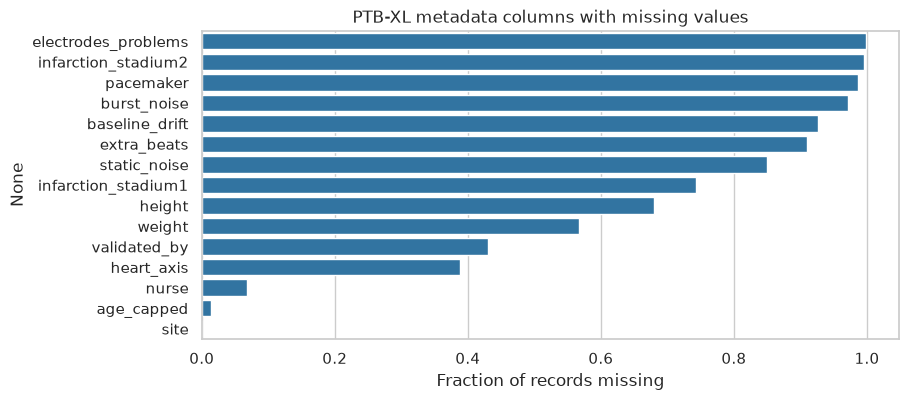

,missing fraction
electrodes_problems,0.999
infarction_stadium2,0.995
pacemaker,0.987
burst_noise,0.972
baseline_drift,0.927
extra_beats,0.911
static_noise,0.850
infarction_stadium1,0.743
height,0.680
weight,0.568


In [8]:
missing = meta.drop(columns=["scp_codes"]).isna().mean().sort_values(ascending=False)
missing = missing[missing > 0].drop("age_band", errors="ignore")
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=missing.to_numpy(), y=missing.index, ax=ax, color="tab:blue")
ax.set(xlabel="Fraction of records missing", title="PTB-XL metadata columns with missing values")
plt.show()
display(missing.round(3).to_frame("missing fraction"))

In [9]:
columns = ["height", "weight", "heart_axis", "nurse"]
by_diagnosis = meta.groupby("abnormal")[columns].apply(lambda values: values.isna().mean())
display(by_diagnosis.rename(index={False: "no abnormal superclass", True: "abnormal superclass"}).round(3))

,height,weight,heart_axis,nurse
abnormal,,,,
no abnormal superclass,0.672,0.464,0.469,0.059
abnormal superclass,0.687,0.647,0.326,0.074


**Patterns of absence.** Is the missingness random, or does it follow the recording date, the device or
other columns? The matrix shows every record (black is missing) ordered by recording date; the heatmap
correlates the missingness indicators of the columns.

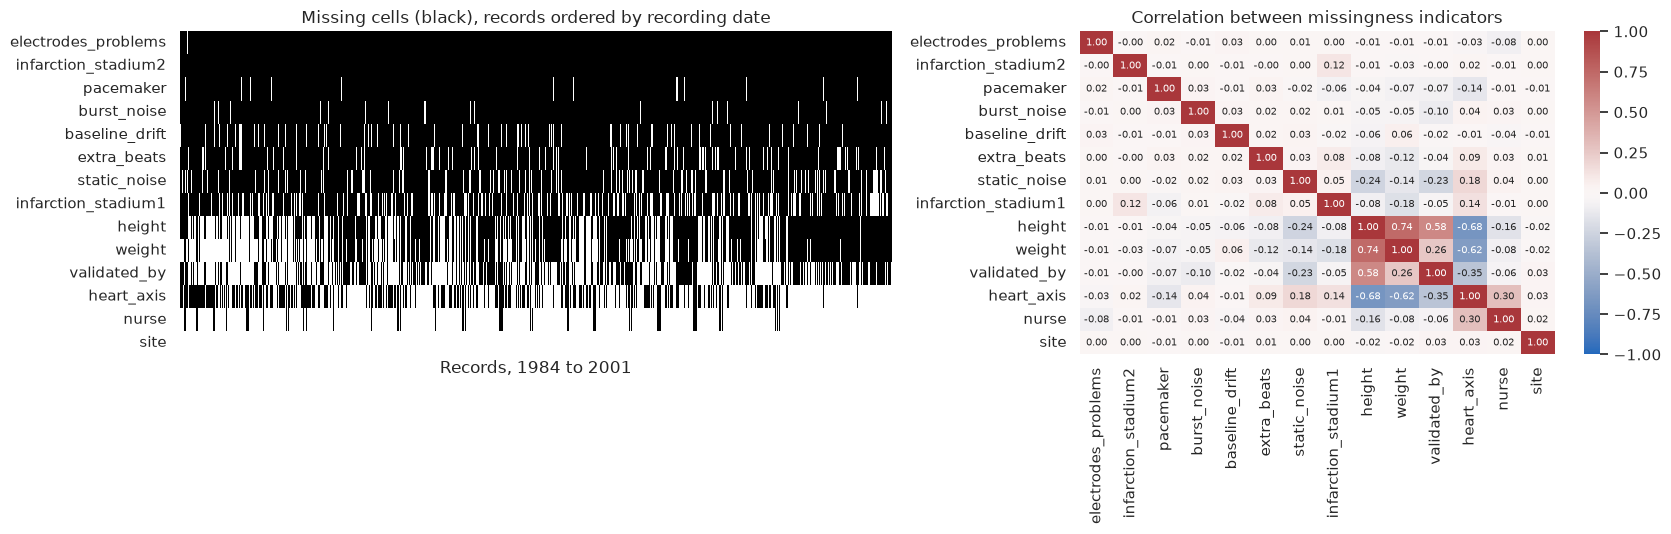

In [10]:
gaps = [column for column in missing.index if column != "age_capped"]
ordered = meta.sort_values("recording_date")[gaps].isna()
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={"width_ratios": [1.2, 1]})
sns.heatmap(ordered.T, cbar=False, cmap="Greys", xticklabels=False, ax=axes[0])
axes[0].set(title="Missing cells (black), records ordered by recording date", xlabel="Records, 1984 to 2001")
sns.heatmap(missing_correlation(meta[gaps]), annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7}, ax=axes[1])
axes[1].set(title="Correlation between missingness indicators")
plt.tight_layout()
plt.show()

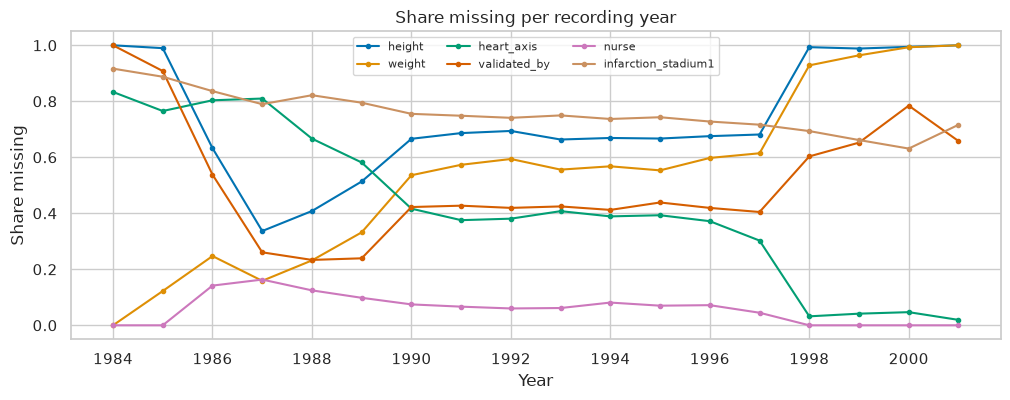

,height,weight,heart_axis,validated_by,nurse,infarction_stadium1
device,,,,,,
AT-6 6,0.06,0.09,0.89,0.00,0.16,0.78
AT-6 C,1.00,1.00,1.00,0.81,1.00,0.64
AT-6 C 5.0,0.56,0.56,0.94,0.46,0.14,0.68
AT-6 C 5.3,0.00,0.00,0.90,0.00,0.16,0.81
AT-6 C 5.5,0.06,0.08,0.89,0.00,0.10,0.80
AT-6 C 5.6,0.02,0.08,0.92,0.00,0.00,0.83
AT-6 C 5.8,0.04,0.04,0.86,0.00,0.16,0.78
AT-60 3,0.96,0.96,0.01,0.00,0.00,0.68
CS-12,0.98,0.98,0.04,0.00,0.00,0.73


In [11]:
tracked = ["height", "weight", "heart_axis", "validated_by", "nurse", "infarction_stadium1"]
yearly_missing = meta.groupby(meta["recording_date"].dt.year)[tracked].apply(lambda values: values.isna().mean())
fig, ax = plt.subplots(figsize=(12, 4))
yearly_missing.plot(ax=ax, marker="o", markersize=3)
ax.set(title="Share missing per recording year", xlabel="Year", ylabel="Share missing")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(fontsize=8, ncol=3)
plt.show()
display(meta.groupby("device")[tracked].apply(lambda values: values.isna().mean()).round(2))

**Finding.** The core fields (patient, fold, SCP codes, age, sex, device) are complete. The gaps are
elsewhere:

- The noise columns (`baseline_drift`, `static_noise`, `burst_noise`, `electrodes_problems`) are empty
  in 85-99% of rows. Empty means "the annotator noted nothing", not "unknown". Section 12 checks these
  annotations against the measured signals.
- Height (68% missing) and weight (57% missing) are sparse, and **they are not missing at random**.
  Height is missing equally often with and without an abnormal finding (69% vs 67%), but weight is
  missing much more often for abnormal records (65% vs 46%). The recorded weights are therefore a
  biased subset. The heart axis goes the other way: it is recorded more often when the ECG is abnormal
  (missing in 33% vs 47%), presumably because cardiologists note it when it matters.
- Age is always present, but it hides a placeholder, checked next.

**Patterns of absence.** The gaps are not random.

- Height, weight and validator go missing together (the missingness indicators correlate 0.74 between
  height and weight and 0.58 between height and validator), and in the opposite direction to the heart
  axis (-0.68 with height, -0.62 with weight).
- The device explains this. Most AT-6 machines record height and weight (missing in 0-9% of their
  records) but rarely a heart axis (missing in 86-94%). `CS100 3`, `CS-12` and `AT-60 3` do the reverse:
  height is missing in 96-100% of their records and the heart axis in only 1-4%. `CS-12 E` records weight
  but not height, and the small `AT-6 C` group records neither.
- The same switch appears over time. From 1998 on, height and weight are almost always missing and the
  heart axis almost always present, because the AT-6 machines stop appearing (section 6).
- The noise columns and the infarction stage are barely related to the other gaps (|r| at most 0.24).

The missingness therefore depends on the recording system and period, not on chance ("missing at random"
given the device, rather than "missing completely at random"). This also explains part of the
diagnosis-dependent gap above: `CS100 3`, the largest device, never records weight and has one of the
highest shares of abnormal records (68%, section 12).

## 4. Implausible and placeholder values

Values that are present but cannot be right. Children legitimately have small heights and weights, so
the size rules only apply to adults.

In [12]:
flags = implausible_rows(meta)
display(flags.sum().to_frame("records"))
suspicious = meta.loc[flags.drop(columns="age 300 (placeholder for > 89)").any(axis=1),
                      ["age", "sex_name", "height", "weight"]]
display(suspicious.sort_values("height"))
children = meta[(meta["age_capped"] < 18) & meta["height"].notna()]
display(children[["age", "height", "weight"]].describe().round(1))

,records
age 300 (placeholder for > 89),293
adult height < 120 cm,12
adult weight < 30 kg,3
weight > 180 kg,5
BMI < 12 or > 70,5


,age,sex_name,height,weight
ecg_id,,,,
9384,79.0,female,6.0,NaN
15207,86.0,female,6.0,NaN
9317,64.0,male,6.0,NaN
6266,60.0,female,66.0,NaN
6430,46.0,female,67.0,NaN
6481,76.0,male,80.0,NaN
15351,84.0,female,90.0,NaN
15514,84.0,female,90.0,NaN
18173,64.0,male,93.0,NaN


,age,height,weight
count,45.0,45.0,42.0
mean,12.4,152.2,48.7
std,4.4,26.2,22.6
min,2.0,85.0,12.0
25%,10.0,144.0,35.2
50%,13.0,160.0,49.5
75%,16.0,170.0,60.0
max,17.0,185.0,120.0


**Finding.** Few values are wrong, but they are clearly wrong:

- **293 records have age 300.** This is PTB-XL's privacy placeholder for patients older than 89. It
  must be treated as "over 89", never as a number. This notebook uses `age_capped`, where it is NaN.
- **12 adults are shorter than 120 cm**, including three at 6 cm, and **3 adults weigh under 30 kg**
  (two at 5 kg). These are data-entry errors, most likely a missing digit or a shifted field.
- The small heights and weights of children (ages 2-17) are consistent with their age and are real,
  with one exception: a 4-year-old recorded at 140 cm and 15 kg.
- 5 weights above 180 kg are possible but extreme; four have no height, so their BMI cannot be checked.

Height and weight should be cleaned with these rules before being used.

## 5. Univariate analysis

Each variable on its own, with the plot that fits its scale: histograms and boxplots for the numeric
variables (the metadata plus five measures computed from every waveform in section 11), bar charts for
the categorical ones. Then the outliers by Tukey's rule (beyond 1.5 interquartile ranges) and the
skewness, with a log transform where it helps.

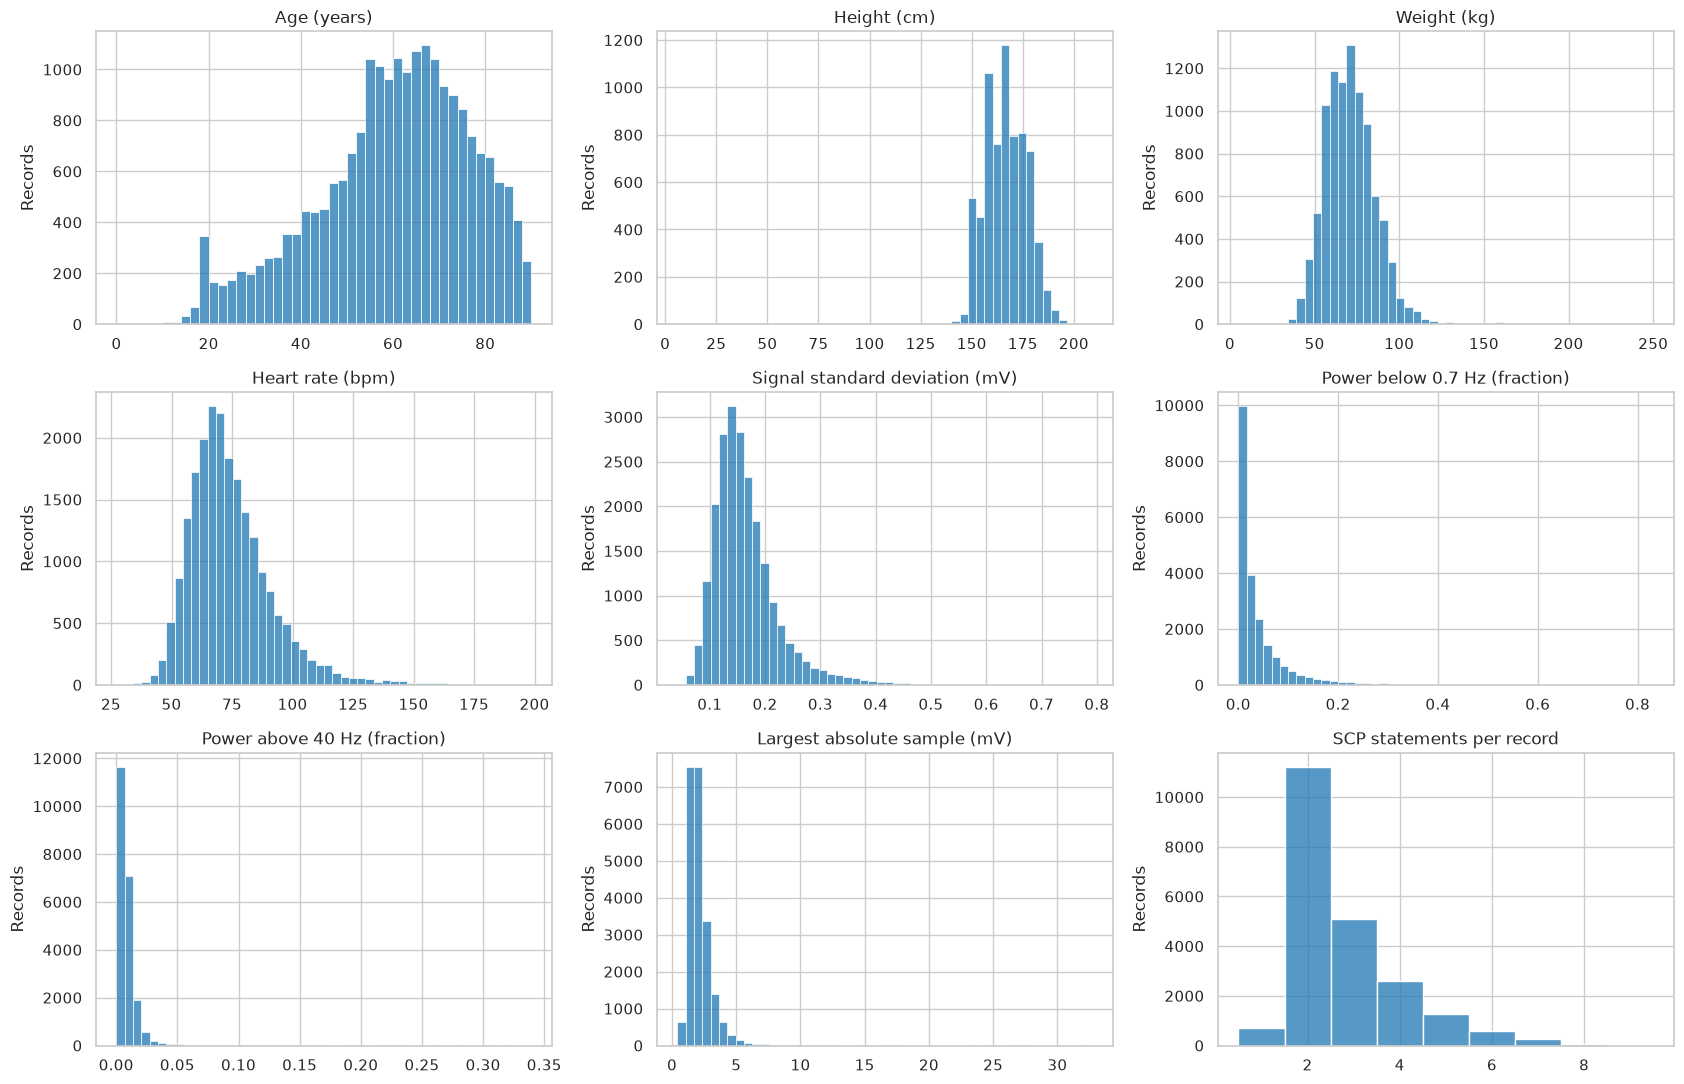

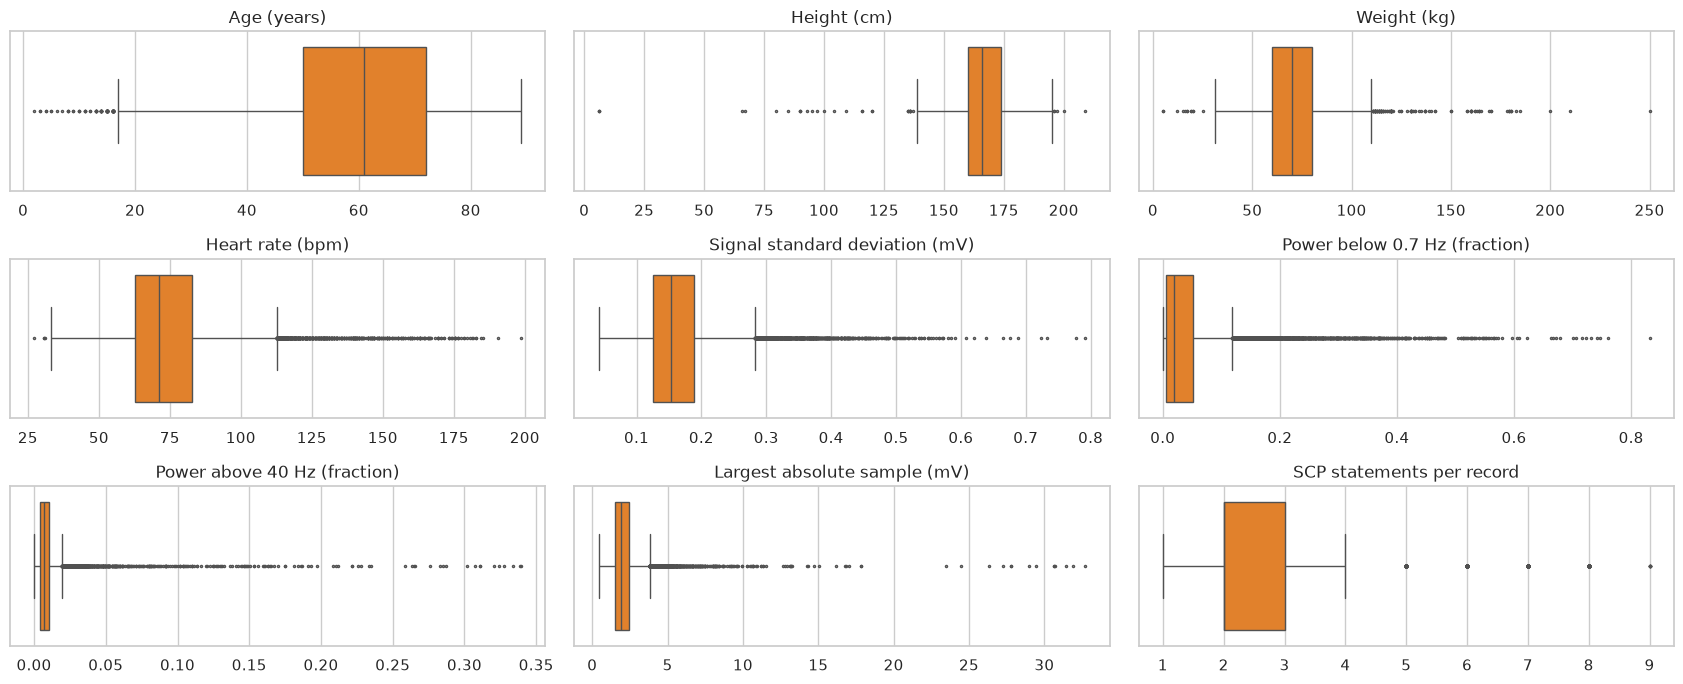

In [13]:
labels = {"age_capped": "Age (years)", "height": "Height (cm)", "weight": "Weight (kg)",
          "heart_rate": "Heart rate (bpm)", "std": "Signal standard deviation (mV)",
          "baseline_fraction": "Power below 0.7 Hz (fraction)", "high_frequency_fraction": "Power above 40 Hz (fraction)",
          "peak_abs_mv": "Largest absolute sample (mV)", "statements": "SCP statements per record"}
values = meta[["age_capped", "height", "weight"]].join(
    summary[["heart_rate", "std", "baseline_fraction", "high_frequency_fraction", "peak_abs_mv"]])
values["statements"] = meta["scp_codes"].apply(len)
fig, axes = plt.subplots(3, 3, figsize=(17, 11))
for axis, (column, label) in zip(axes.flat, labels.items()):
    bins = {"age_capped": np.arange(0, 92, 2), "statements": np.arange(0.5, 10.5)}.get(column, 50)
    sns.histplot(values[column].dropna(), bins=bins, ax=axis, color="tab:blue")
    axis.set(title=label, xlabel="", ylabel="Records")
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(3, 3, figsize=(17, 7))
for axis, (column, label) in zip(axes.flat, labels.items()):
    sns.boxplot(x=values[column].dropna(), ax=axis, color="tab:orange", fliersize=1.5)
    axis.set(title=label, xlabel="")
plt.tight_layout()
plt.show()

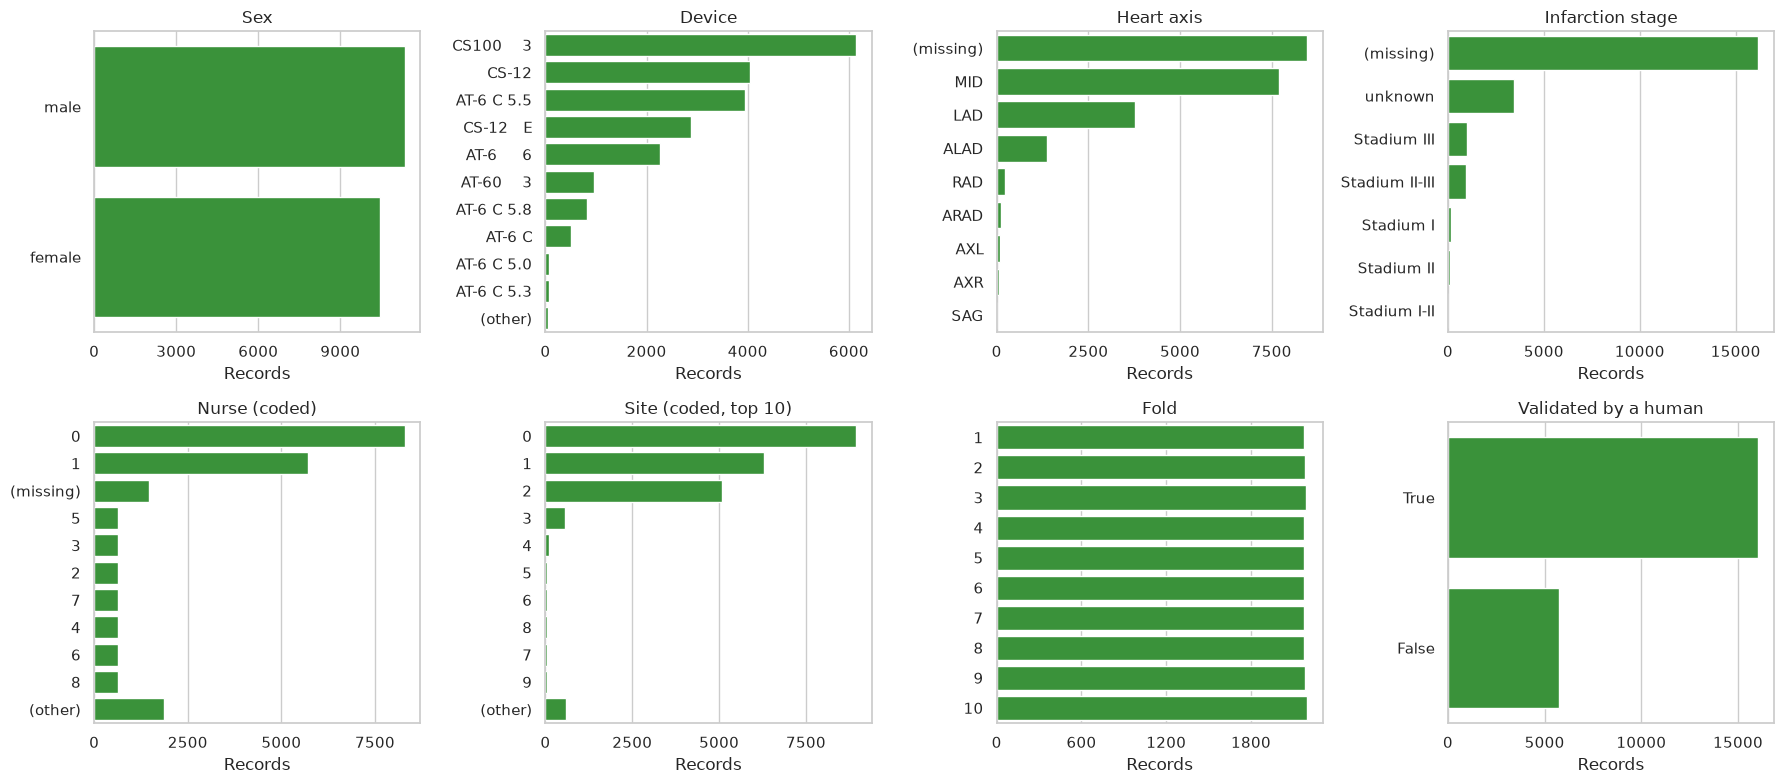

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
shown = {"sex_name": "Sex", "device": "Device", "heart_axis": "Heart axis", "infarction_stadium1": "Infarction stage",
         "nurse": "Nurse (coded)", "site": "Site (coded, top 10)", "strat_fold": "Fold",
         "validated_by_human": "Validated by a human"}
for axis, (column, title) in zip(axes.flat, shown.items()):
    counts = frequencies(meta[column], top=10)["records"]
    if column == "strat_fold":
        counts = counts.sort_index(key=lambda index: index.astype(int))
    sns.barplot(x=counts.to_numpy(), y=counts.index.astype(str), ax=axis, color="tab:green")
    axis.set(title=title, xlabel="Records", ylabel="")
    axis.xaxis.set_major_locator(MaxNLocator(4))
plt.tight_layout()
plt.show()

### Reading Tukey's rule and the log10 comparison

**Tukey's rule:** sort a variable's observed values and find `Q1` (the 25th percentile) and `Q3`
(the 75th percentile). The **interquartile range**, `IQR = Q3 - Q1`, describes the spread of the
middle 50% of the observations. Flag a value when:

```text
value < Q1 - 1.5 * IQR    or    value > Q3 + 1.5 * IQR
```

For the heart-rate estimates in this dataset, Q1 is 62.76 bpm and Q3 is 82.76 bpm. This gives
fences of about 32.77 and 112.75 bpm. The following summary counts values beyond those fences.
A fence is a statistical inspection rule, not a clinical normal range. A flagged value can be a
valid unusual observation, a measurement artifact or a data-entry error. We do not delete it merely
because it crosses a fence. The `outlier_share` denominator is the non-missing count for that variable;
these counts are calculated on the **raw values**, before the log comparison.

**Why log10?** A right-skewed distribution has many smaller values and a few much larger ones. A
logarithm compresses that long tail: values 1, 10 and 100 become 0, 1 and 2. Equal steps on this
axis therefore represent tenfold ratios, rather than equal additions in the original unit. Values
between 0 and 1 have negative logarithms; that is expected for the power fractions here.

The plots compare raw values (top row, blue) with log10 values (bottom row, red). The skewness table
checks whether the shape becomes more balanced; zero means no skewness, not proof of a normal
(Gaussian) distribution. Base 10 makes powers of ten easy to read. A natural logarithm would have
the same skewness because it differs from log10 only by a positive constant factor.

This is an exploratory comparison. It does not overwrite `values`, transform the ECG waveforms,
train a model or change the localization algorithm. A log transform is a possible preprocessing choice
for a later analysis, not something every variable needs. In particular, it cannot repair an
implausible measurement such as an adult weight recorded as 5 kg.

Log10 requires **strictly positive** inputs. Missing observations are omitted. The code explicitly
checks for zero or negative values rather than silently dropping them or adding an arbitrary offset.
All six compared columns pass that check in the current data. This transform must not be applied
directly to signed ECG voltage samples, which can be zero or negative.


,count,50%,skew,kurtosis,outliers,outlier_share
age_capped,21506.0,61.000,-0.558,-0.183,92,0.004
height,6974.0,166.000,-2.007,24.952,34,0.005
weight,9421.0,70.000,1.296,6.951,127,0.013
heart_rate,21799.0,71.259,1.498,4.289,751,0.034
std,21799.0,0.152,2.027,7.779,1013,0.046
baseline_fraction,21799.0,0.020,3.717,19.992,1867,0.086
high_frequency_fraction,21799.0,0.007,11.905,200.412,1291,0.059
peak_abs_mv,21799.0,1.905,9.289,175.874,1091,0.050
statements,21799.0,2.000,1.467,2.205,2170,0.100


,raw_skew,log_skew
weight,1.30,-0.48
heart_rate,1.50,0.51
std,2.03,0.45
baseline_fraction,3.72,-0.21
high_frequency_fraction,11.91,0.05
peak_abs_mv,9.29,0.86


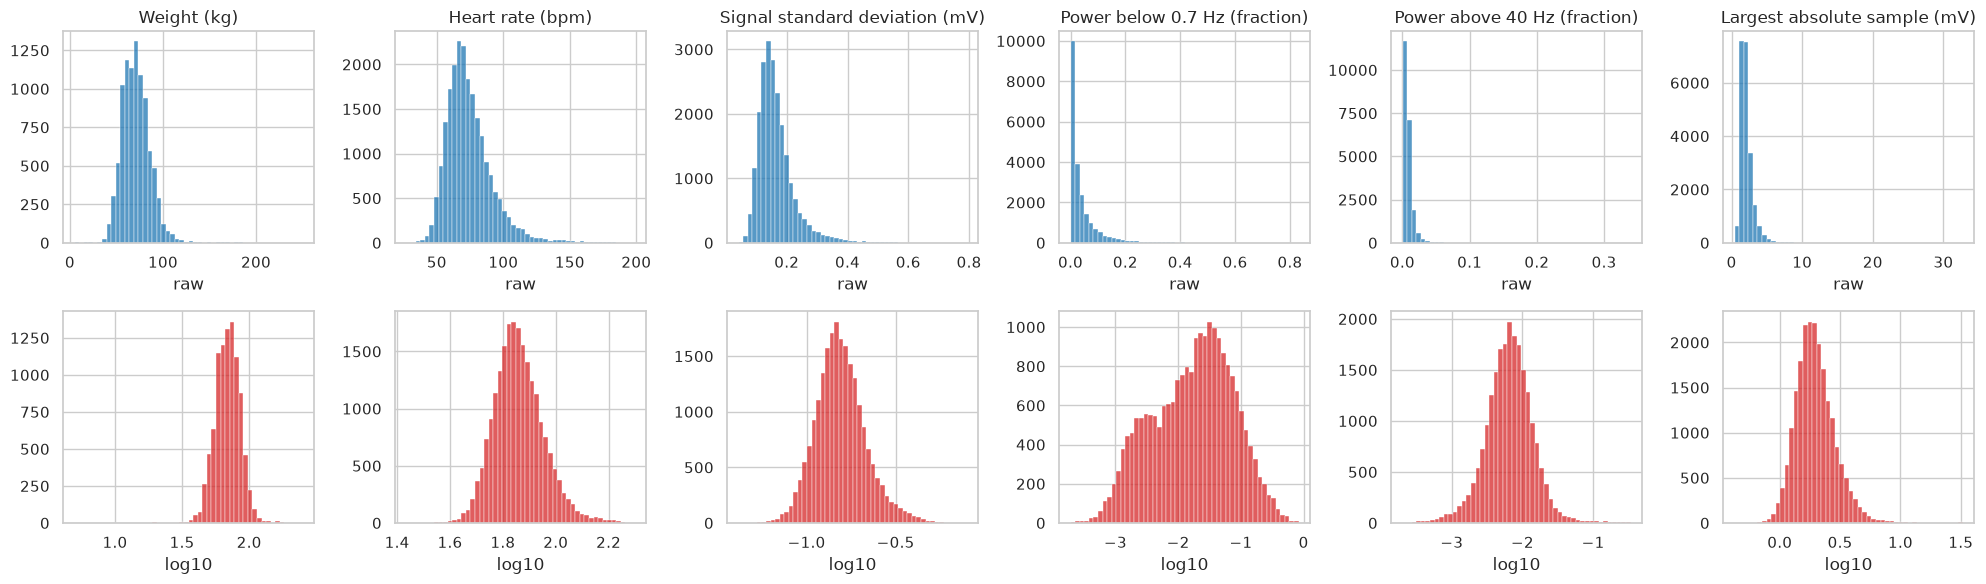

In [15]:
display(numeric_summary(values, list(labels))[["count", "50%", "skew", "kurtosis", "outliers", "outlier_share"]].round(3))
skewed = ["weight", "heart_rate", "std", "baseline_fraction", "high_frequency_fraction", "peak_abs_mv"]
nonpositive = values[skewed].le(0).sum()
if nonpositive.any():
    raise ValueError(f"log10 requires positive values; nonpositive counts: {nonpositive.to_dict()}")
display(log_skew(values, skewed).round(2))
fig, axes = plt.subplots(2, 6, figsize=(20, 6))
for column, top, bottom in zip(skewed, axes[0], axes[1]):
    sns.histplot(values[column].dropna(), bins=50, ax=top, color="tab:blue")
    sns.histplot(np.log10(values[column].dropna()), bins=50, ax=bottom, color="tab:red")
    top.set(title=labels[column], xlabel="raw", ylabel="")
    bottom.set(xlabel="log10", ylabel="")
plt.tight_layout()
plt.show()

**Finding.**

- Age is the only metadata variable with a near-symmetric shape (skewness -0.56, a slight tail toward
  the young). It needs no transform.
- Height has a skewness of -2.0 and a kurtosis of 25 only because of the impossible values down to 6 cm;
  the bulk is symmetric around 166 cm. Weight is right-skewed (1.30); log10 reduces its skewness
  to -0.48, reversing the direction of the tail. Both views are useful, but neither repairs
  implausible recorded weights.
- The waveform measures are strongly right-skewed: power above 40 Hz (skewness 11.9), the largest
  sample (9.3), power below 0.7 Hz (3.7), the signal standard deviation (2.0) and the heart rate (1.5).
  A log10 transform brings all of them between -0.21 and 0.86 in this exploratory comparison.
  This supports considering a log transform for a later analysis, but does not establish that it
  improves a model. The original values remain unchanged.
- Tukey's rule flags 3-9% of records on each waveform measure, for example 751 heart rates and 1,867
  baseline fractions. The flags identify unusual values, not their cause: they can reflect fast rhythms, large
  signal amplitudes or noise. Section 11 separately examines samples above 10 mV. These statistical
  outliers remain in the data; the log plots are an additional view. Section 4 uses separate
  plausibility checks for metadata errors, which are handled in section 9.
- Among the categorical variables, the three largest devices record 65% of the ECGs, three sites 93% and
  two nurses 64%. Most records (74%) have no infarction stage.

## 6. Who is in the dataset, and when

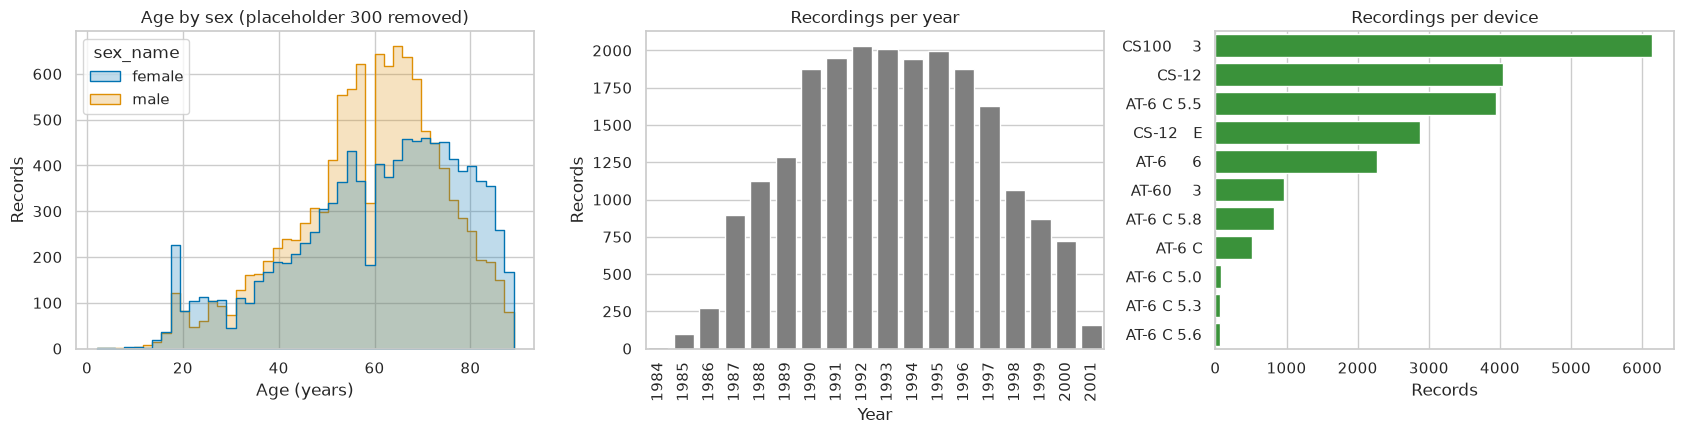

,count,mean,std,min,25%,50%,75%,max
sex_name,,,,,,,,
female,10220.0,60.4,18.0,3.0,49.0,63.0,75.0,89.0
male,11286.0,58.8,15.5,2.0,50.0,60.0,69.0,89.0


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(meta, x="age_capped", hue="sex_name", bins=45, element="step", ax=axes[0])
axes[0].set(title="Age by sex (placeholder 300 removed)", xlabel="Age (years)", ylabel="Records")
sns.countplot(x=meta["recording_date"].dt.year, ax=axes[1], color="tab:gray")
axes[1].set(title="Recordings per year", xlabel="Year", ylabel="Records")
axes[1].tick_params(axis="x", rotation=90)
sns.countplot(meta, y="device", order=meta["device"].value_counts().index, ax=axes[2], color="tab:green")
axes[2].set(title="Recordings per device", xlabel="Records", ylabel="")
plt.tight_layout()
plt.show()
display(meta.groupby("sex_name")["age_capped"].describe().round(1))

**Finding.** The population is older (median age 61) and slightly male (52%). Women are older than men
in this cohort (a visibly later age peak). Recordings come from 11 device models, with `CS100 3` the
largest single group. Section 12 shows that devices differ in their signals.

**Trends over time.** Recordings span 1984 to 2001. Does the case mix or the way data were recorded drift
over the years?

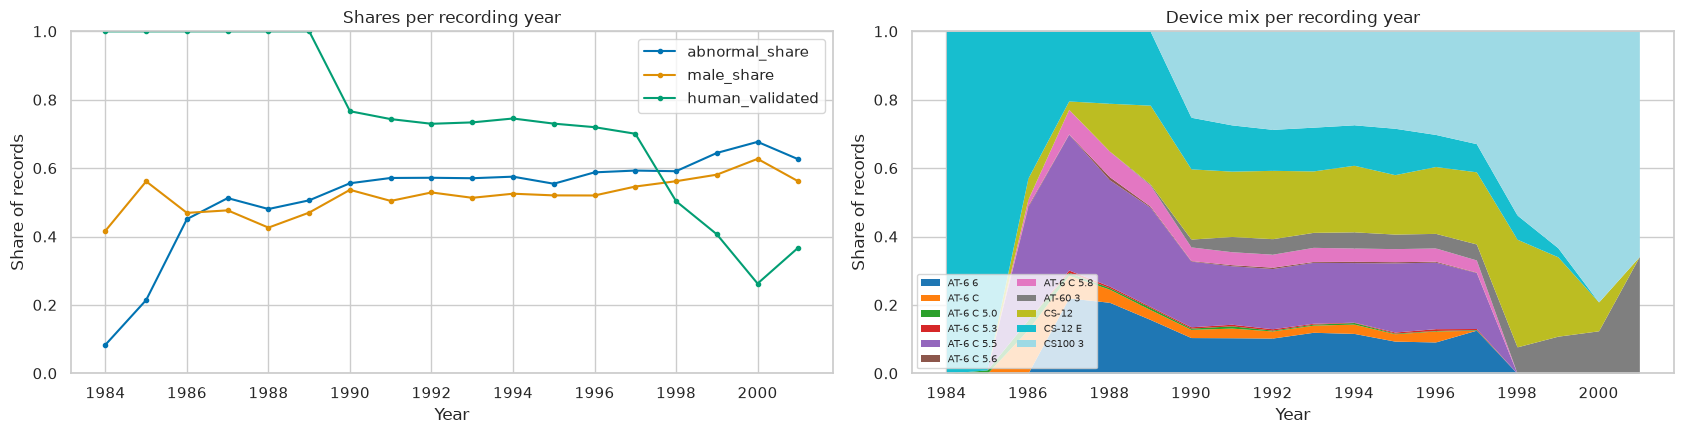

year,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001
records,12.00,98.00,275.00,894.00,1122.00,1283.00,1875.00,1952.00,2027.00,2009.00,1946.00,1997.00,1877.00,1626.00,1061.00,866.00,724.00,155.00
abnormal_share,0.08,0.21,0.45,0.51,0.48,0.51,0.56,0.57,0.57,0.57,0.58,0.55,0.59,0.59,0.59,0.64,0.68,0.63
median_age,30.50,37.00,54.00,63.00,61.00,63.00,61.00,61.00,61.00,62.00,62.00,61.00,63.00,62.00,60.00,60.50,61.00,65.00
male_share,0.42,0.56,0.47,0.48,0.43,0.47,0.54,0.50,0.53,0.51,0.53,0.52,0.52,0.55,0.56,0.58,0.63,0.56
human_validated,1.00,1.00,1.00,1.00,1.00,1.00,0.77,0.74,0.73,0.73,0.75,0.73,0.72,0.70,0.50,0.41,0.26,0.37


Spearman correlation between year and abnormal share: 0.95


In [17]:
year = meta["recording_date"].dt.year.rename("year")
yearly = meta.groupby(year).agg(records=("abnormal", "size"), abnormal_share=("abnormal", "mean"),
                                median_age=("age_capped", "median"), male_share=("male", "mean"),
                                human_validated=("validated_by_human", "mean"))
fig, axes = plt.subplots(1, 2, figsize=(17, 4.5))
yearly[["abnormal_share", "male_share", "human_validated"]].plot(ax=axes[0], marker="o", markersize=3)
axes[0].set(title="Shares per recording year", xlabel="Year", ylabel="Share of records", ylim=(0, 1))
devices = pd.crosstab(year, meta["device"].str.split().str.join(" "), normalize="index")
devices.plot.area(ax=axes[1], linewidth=0, colormap="tab20")
axes[1].set(title="Device mix per recording year", xlabel="Year", ylabel="Share of records", ylim=(0, 1))
axes[1].legend(fontsize=7, ncol=2, loc="lower left")
for axis in axes:
    axis.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()
display(yearly.round(2).T)
print(f"Spearman correlation between year and abnormal share: {yearly.reset_index()[['year', 'abnormal_share']].corr('spearman').iloc[0, 1]:.2f}")

**Finding: the dataset drifts over time.**

- The share of abnormal records rises from 45% in 1986 to 68% in 2000 (Spearman correlation between year
  and abnormal share 0.95). The first two years have very few records (12 in 1984, 98 in 1985), so their
  low shares are not reliable.
- The median age stays between 60 and 65 from 1987 on, so an older population does not explain the rise.
- The share validated by a human drops from 100% before 1990 to 26-50% from 1998 on.
- The device mix changes abruptly in 1998: the AT-6 machines disappear and `CS100 3`, `CS-12` and
  `AT-60 3` take over. This is the same break seen in the missing values (section 3).

Year, device, validation and case mix are therefore entangled.

## 7. Diagnostic statements

Each record lists SCP-ECG statements with a likelihood (0-100). Statements are *diagnostic* (grouped
into five superclasses: NORM normal, MI myocardial infarction, STTC ST/T change, CD conduction
disturbance, HYP hypertrophy), *form* or *rhythm*. Below, a superclass counts as present when any of its
statements is listed, the convention of the PTB-XL benchmark.

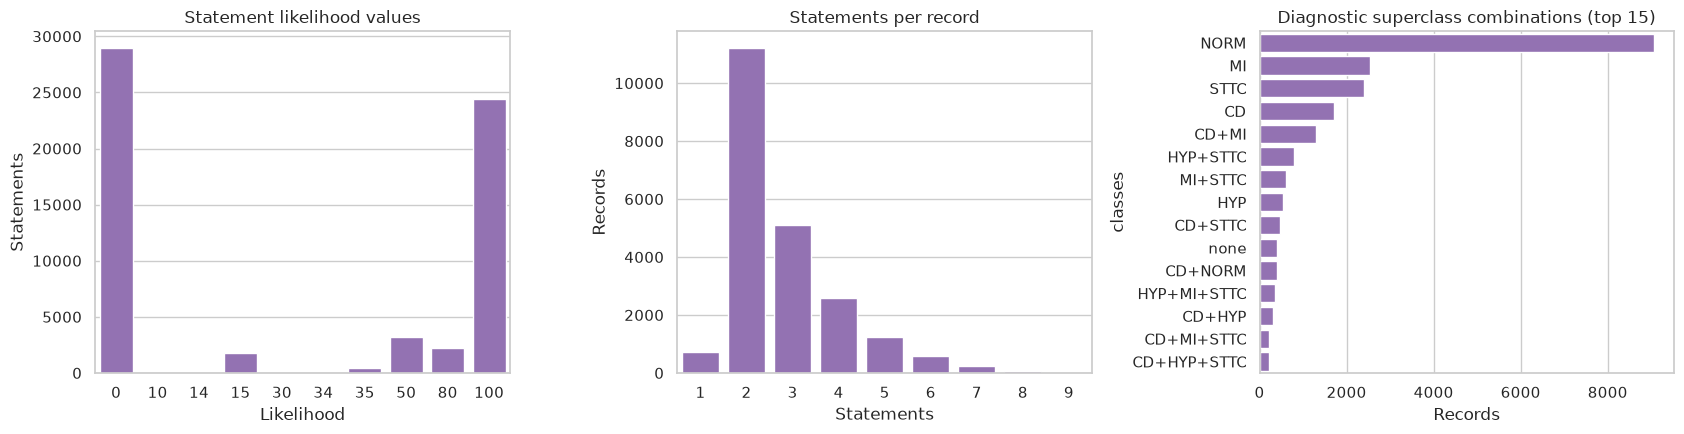

,share of records
NORM,0.436
MI,0.251
STTC,0.240
CD,0.225
HYP,0.122
abnormal,0.565


Records with NORM and an abnormal superclass at the same time: 445
Records with no diagnostic statement at all: 411


In [18]:
likelihoods = pd.Series([value for codes in meta["scp_codes"] for value in codes.values()])
codes_per_record = meta["scp_codes"].apply(len)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.countplot(x=likelihoods.astype(int), ax=axes[0], color="tab:purple")
axes[0].set(title="Statement likelihood values", xlabel="Likelihood", ylabel="Statements")
sns.countplot(x=codes_per_record, ax=axes[1], color="tab:purple")
axes[1].set(title="Statements per record", xlabel="Statements", ylabel="Records")
top = meta["classes"].value_counts().head(15)
sns.barplot(x=top.to_numpy(), y=top.index, ax=axes[2], color="tab:purple")
axes[2].set(title="Diagnostic superclass combinations (top 15)", xlabel="Records")
plt.tight_layout()
plt.show()
display(meta[[*SUPERCLASSES, "abnormal"]].mean().round(3).to_frame("share of records"))
conflict = meta["NORM"] & meta["abnormal"]
print(f"Records with NORM and an abnormal superclass at the same time: {conflict.sum()}")
print(f"Records with no diagnostic statement at all: {(meta['classes'] == 'none').sum()}")

**Finding.** Most likelihoods are 100 or 0; in PTB-XL, 0 means "likelihood not specified", not
"absent". Records carry a median of 2 statements, and superclasses overlap heavily (MI with CD, HYP
with STTC). 44% of records are NORM and 57% have at least one abnormal superclass. The two overlap
slightly: some records are NORM and also carry an abnormal statement, which is a genuine annotation
conflict. 411 records have no diagnostic statement at all, only rhythm or form codes (pacemaker,
atrial fibrillation, flutter...).

**Cardinality of the statements.** The 71 SCP statements are a high-cardinality, multi-label variable. How
concentrated are they?

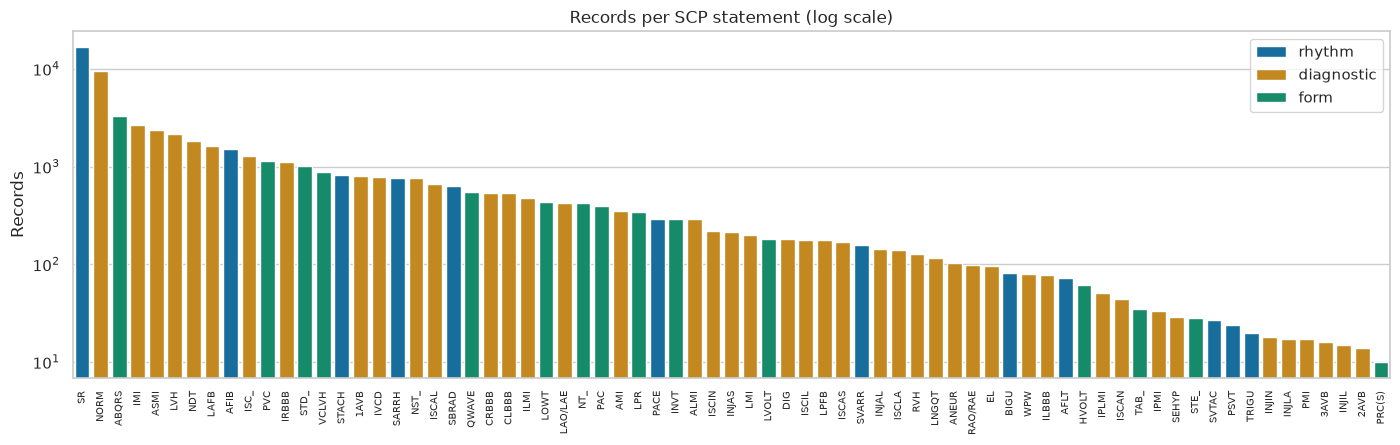

Statements needed to cover 80% / 95% of all listed statements: 17 / 36
Statements listed in fewer than 100 records: 23 of 71


In [19]:
code_counts = pd.Series([code for codes in meta["scp_codes"] for code in codes]).value_counts()
kind = statements.loc[code_counts.index, ["diagnostic", "form", "rhythm"]].fillna(0).idxmax(axis=1)
fig, ax = plt.subplots(figsize=(17, 4.5))
sns.barplot(x=code_counts.index, y=code_counts.to_numpy(), hue=kind.to_numpy(), dodge=False, ax=ax)
ax.set(yscale="log", title="Records per SCP statement (log scale)", xlabel="", ylabel="Records")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.show()
cumulative = code_counts.cumsum() / code_counts.sum()
print(f"Statements needed to cover 80% / 95% of all listed statements: "
      f"{(cumulative < 0.8).sum() + 1} / {(cumulative < 0.95).sum() + 1}")
print(f"Statements listed in fewer than 100 records: {(code_counts < 100).sum()} of {len(code_counts)}")

**Finding.** The statements have a long tail: 17 of the 71 cover 80% of all listed statements and 36
cover 95%, while 23 statements appear in fewer than 100 records. Sinus rhythm (SR) and NORM dominate.
Treating each of the 71 statements as its own class would leave many classes with too few examples,
which is why they are grouped into the five superclasses.

## 8. The target variable and class imbalance

The project's binary label marks a record **negative** when its only statements are NORM and sinus rhythm
(SR), and **positive** when it carries any MI, STTC, CD or HYP statement without NORM. Records that mix
NORM with other statements, or have no diagnostic statement, stay **unlabeled**.

,records,share
label,,
positive,11874,0.545
negative,7252,0.333
unlabeled,2673,0.123


Among labeled records: 62.1% positive; positive:negative = 1.64:1


,HYP,CD,STTC,MI
share of positives,0.223,0.378,0.438,0.461


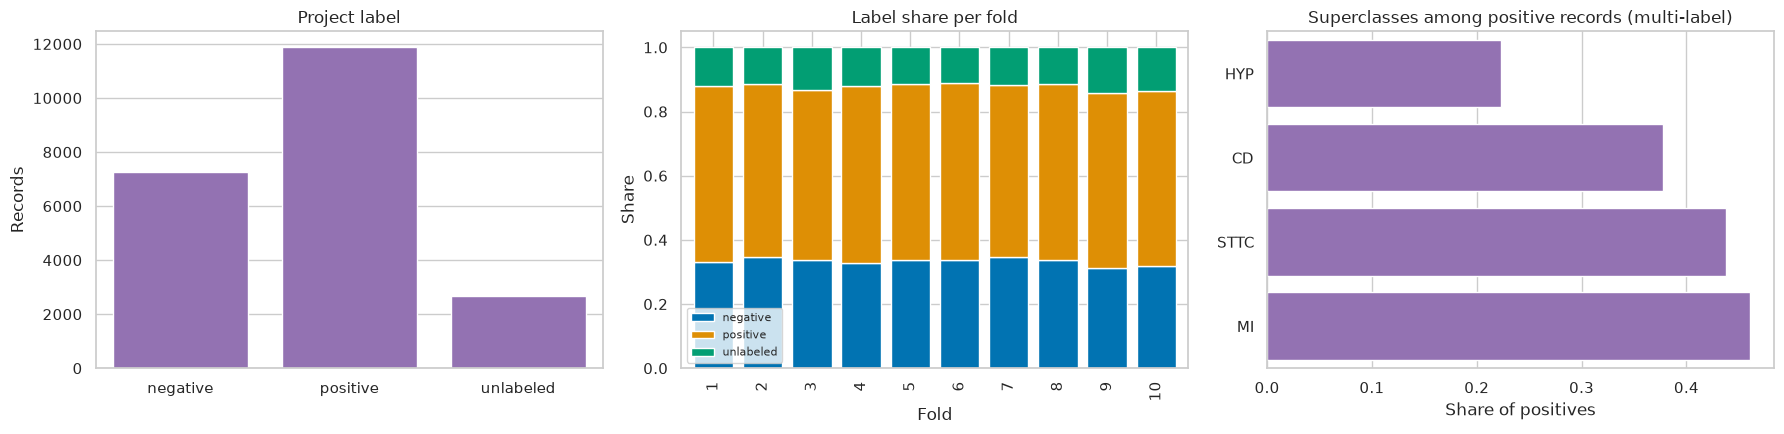

In [20]:
meta["label"] = meta["scp_codes"].apply(project_label, classes=classes)
target = meta["label"].map({1.0: "positive", 0.0: "negative"}).fillna("unlabeled")
balance = frequencies(target)
display(balance.round(3))
labeled = meta.dropna(subset=["label"])
print(f"Among labeled records: {labeled['label'].mean():.1%} positive; positive:negative = "
      f"{labeled['label'].mean() / (1 - labeled['label'].mean()):.2f}:1")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
sns.barplot(x=balance.index, y=balance["records"], ax=axes[0], color="tab:purple", order=["negative", "positive", "unlabeled"])
axes[0].set(title="Project label", xlabel="", ylabel="Records")
pd.crosstab(meta["strat_fold"], target, normalize="index").plot.bar(stacked=True, ax=axes[1], width=0.8)
axes[1].set(title="Label share per fold", xlabel="Fold", ylabel="Share")
axes[1].legend(fontsize=8)
superclass_share = labeled.loc[labeled["label"] == 1, SUPERCLASSES[1:]].mean().sort_values()
sns.barplot(x=superclass_share.to_numpy(), y=superclass_share.index, ax=axes[2], color="tab:purple")
display(superclass_share.round(3).to_frame("share of positives").T)
axes[2].set(title="Superclasses among positive records (multi-label)", xlabel="Share of positives", ylabel="")
plt.tight_layout()
plt.show()

**Finding.** 54.5% of records are positive, 33.3% negative and 12.3% unlabeled. Among labeled records the
split is 62% positive to 38% negative (1.64 positives per negative), a moderate imbalance. It runs in the
opposite direction to a screening population, because PTB-XL is a hospital cohort, and it depends heavily
on age: only 18% of records under 30 have an abnormal superclass (section 10). Every fold has the same
label shares, so any split by fold keeps the balance. Within the positive class the superclasses are
imbalanced too: MI appears in 46% of positives, STTC in 44%, CD in 38% and
HYP in only 22%.

## 9. Preprocessing

The problems found above are fixed in `ecg_experiment/eda/ptbxl_cleaning.py`. Every step is logged with
the number of records it touches; the justification of each step follows the table.

In [21]:
clean, steps = clean_metadata(meta, classes, summary)
with pd.option_context("display.max_colwidth", 90):
    display(steps)
metadata_only = raw.drop(columns=["scp_codes", "filename_lr", "filename_hr"])
print(f"Exact duplicate rows: {raw.drop(columns='scp_codes').duplicated().sum()}; "
      f"rows identical except the file names: {metadata_only.duplicated().sum()}")
twins = meta.loc[metadata_only.duplicated(keep=False), "filename_hr"]
twin_signals = [read_signal(name)[0] for name in twins]
print(f"ecg_id {', '.join(map(str, twins.index))}: largest sample difference between the two signals "
      f"{np.abs(twin_signals[0] - twin_signals[1]).max():.2f} mV")
print(f"Before: {meta.shape[0]:,} records x {raw.shape[1]} raw columns; after: {clean.shape[0]:,} records x {clean.shape[1]} columns")

,column,problem,action,records
0,age,300 is a placeholder for over 89,"set to 90, flag age_over_89",293
1,height,implausible adult value or BMI,set to missing,17
2,weight,implausible adult value or BMI,set to missing,5
3,height,missing,"flag height_observed, fill height_filled with sex and age-band median",14842
4,weight,missing,"flag weight_observed, fill weight_filled with sex and age-band median",12383
5,baseline_drift ... pacemaker,"free text, distinct values: baseline_drift (317), static_noise (124), burst_noise (103...",replace by presence flags has_*,6610
6,"nurse, site, validated_by",float-coded IDs with gaps,"convert to categories, gaps become unknown",10370
7,site,"51 sites, most with few records",merge sites under 1% of records into other,914
8,heart_axis,missing when not annotated,new category not recorded,8468
9,infarction_stadium1,missing when there is no infarction,new category none,16187


Exact duplicate rows: 0; rows identical except the file names: 1
ecg_id 11842, 11843: largest sample difference between the two signals 1.23 mV
Before: 21,799 records x 27 raw columns; after: 21,798 records x 45 columns


Why each step.

- Age 300 to 90, with a flag. The value means "over 89". Dropping these 293 records (1.3%) would
  remove the oldest patients, the group with the most abnormal ECGs. Setting 90 keeps the order of ages,
  and `age_over_89` keeps the fact that the true age is unknown.
- Implausible height and weight to missing. An adult cannot be 6 cm tall or weigh 5 kg, and the true
  value cannot be recovered, so 17 heights and 5 weights become missing. Children are judged separately,
  because their small values are real.
- Height and weight gaps: flag, then fill by group. They are missing in 68% and 57% of records, and
  the gaps depend on the device and period (section 3). Deleting incomplete rows would discard two thirds
  of the data and change the device and period mix, so the rows are kept. `height_observed` and
  `weight_observed` record what was measured, and `*_filled` uses the median of the same sex and age
  band for analyses that need a complete column.
- Heart axis and infarction stage: an explicit category. Here an empty cell has a meaning ("not
  annotated", "no infarction"), so it becomes the category `not recorded` or `none` instead of being
  imputed. `infarction_stadium2` is 99.5% empty and is dropped.
- Noise, extra-beat and pacemaker columns: presence flags. They are free text listing the affected
  leads in German shorthand, with 4 to 317 spellings each. What matters for this analysis is whether a
  problem was noted, so each becomes a boolean (`has_*`). This removes the high cardinality.
- Nurse, site, validator: categories. They are codes, not quantities, so they are stored as text with
  `unknown` for gaps. Sites under 1% of records are merged into `other`, which takes the site from 51
  values to 5.
- Report and the 100 Hz file name: dropped. The report is free text with 9,887 distinct values, and
  the SCP statements already encode it. The 100 Hz file is a smoothed copy of the 500 Hz one (section 14).
- SCP statements: superclasses and the label. The 71 statements become five superclass flags, a
  statement count and the binary project label.
- Signal problems. The record with a dead lead is dropped, because a whole lead is missing. The 47
  records with artifact spikes and the 7 with a limb-lead mismatch are kept and flagged, because the rest
  of the signal is usable.
- Tukey outliers in the waveform measures are kept. The statistical rule does not establish
  whether their cause is physiological or an artifact. The log comparison in section 5 reduces
  skewness for display; this preprocessing step does not apply that transform.
- Duplicates. There are no exact duplicate rows. ECGs 11842 and 11843 share all metadata (same
  patient, same second), but their signals differ, so both are kept. Repeat ECGs of the same patient are
  expected (section 1) and are handled by keeping each patient in one fold.

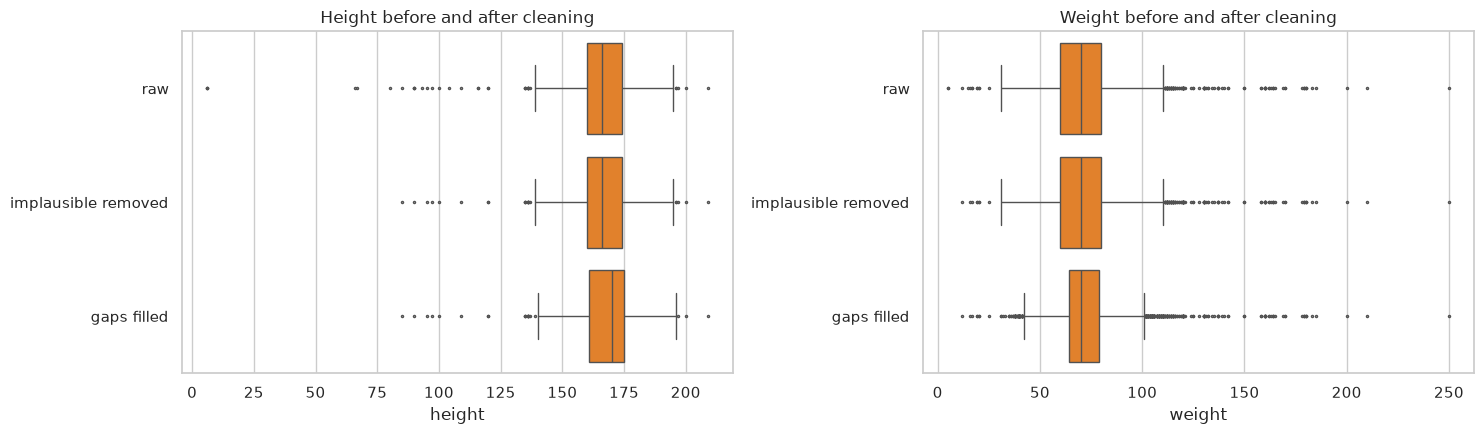

raw                            clean                             filled                          
         count   mean   std  min    max   count   mean   std   min    max    count   mean   std   min    max
height  6974.0  166.7  10.9  6.0  209.0  6956.0  166.9  10.0  85.0  209.0  21798.0  168.2   7.7  85.0  209.0
weight  9421.0   71.0  15.9  5.0  250.0  9415.0   71.0  15.8  12.0  250.0  21798.0   71.2  12.0  12.0  250.0

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for axis, column in zip(axes, ["height", "weight"]):
    stages = pd.DataFrame({"raw": meta[column], "implausible removed": clean[column],
                           "gaps filled": clean[f"{column}_filled"]}).melt(var_name="stage").dropna()
    sns.boxplot(stages, x="value", y="stage", ax=axis, fliersize=1.5, color="tab:orange")
    axis.set(title=f"{column.capitalize()} before and after cleaning", xlabel=column, ylabel="")
plt.tight_layout()
plt.show()
comparison = pd.DataFrame({
    "raw": meta[["height", "weight"]].describe().loc[["count", "mean", "std", "min", "max"]].stack(),
    "clean": clean[["height", "weight"]].describe().loc[["count", "mean", "std", "min", "max"]].stack(),
    "filled": clean[["height_filled", "weight_filled"]].rename(columns=lambda name: name.split("_")[0])
              .describe().loc[["count", "mean", "std", "min", "max"]].stack(),
}).unstack(0)
display(comparison.round(1))

In [23]:
before = {"site": meta["site"].nunique(), "baseline_drift": meta["baseline_drift"].nunique(),
          "static_noise": meta["static_noise"].nunique(), "extra_beats": meta["extra_beats"].nunique(),
          "report": meta["report"].nunique(), "scp_codes (statements)": len(code_counts)}
after = {"site": clean["site"].nunique(), "baseline_drift": clean["has_baseline_drift"].nunique(),
         "static_noise": clean["has_static_noise"].nunique(), "extra_beats": clean["has_extra_beats"].nunique(),
         "report": 0, "scp_codes (statements)": len(SUPERCLASSES)}
display(pd.DataFrame({"distinct values before": before, "after": after}))
remaining = clean.isna().sum()
display(remaining[remaining > 0].to_frame("missing after cleaning"))
clean.to_parquet(OUTPUT_DIR / "ptbxl_clean_metadata.parquet")

,distinct values before,after
site,51,5
baseline_drift,317,2
static_noise,124,2
extra_beats,128,2
report,9887,0
scp_codes (statements),71,5


,missing after cleaning
height,14842
weight,12383
bmi,15059
label,2673


**Finding.** The clean table keeps 21,798 of 21,799 records in 45 columns. The box plots show what each
step does. Removing implausible values takes away the impossible adult heights (down to 6 cm) and the
4-year-old at 140 cm and 15 kg, while the other children's heights (85-185 cm) remain. Filling the gaps
squeezes the distribution (weight standard deviation from 15.8 to 12.0 kg, height from 10.0 to 7.7 cm),
because most values are now group medians. The filled columns therefore serve complete-case tables, not
measurement. The high-cardinality columns are now small: site from 51 values to 5, the noise columns from
up to 317 to 2, and the statements from 71 to 5 superclasses. The only gaps left are genuine: height,
weight and BMI where they were never measured, and the label for the 2,673 records the rule leaves
undecided.

## 10. Bivariate and multivariate analysis

Relationships between variables on the clean table: rank (Spearman) and linear (Pearson) correlations
between the numeric and binary variables, including the target; Cramér's V between the categorical ones;
co-occurrence of the superclasses; and the distribution of the main variables per target class. Spearman
is the main measure because several variables are skewed or binary.

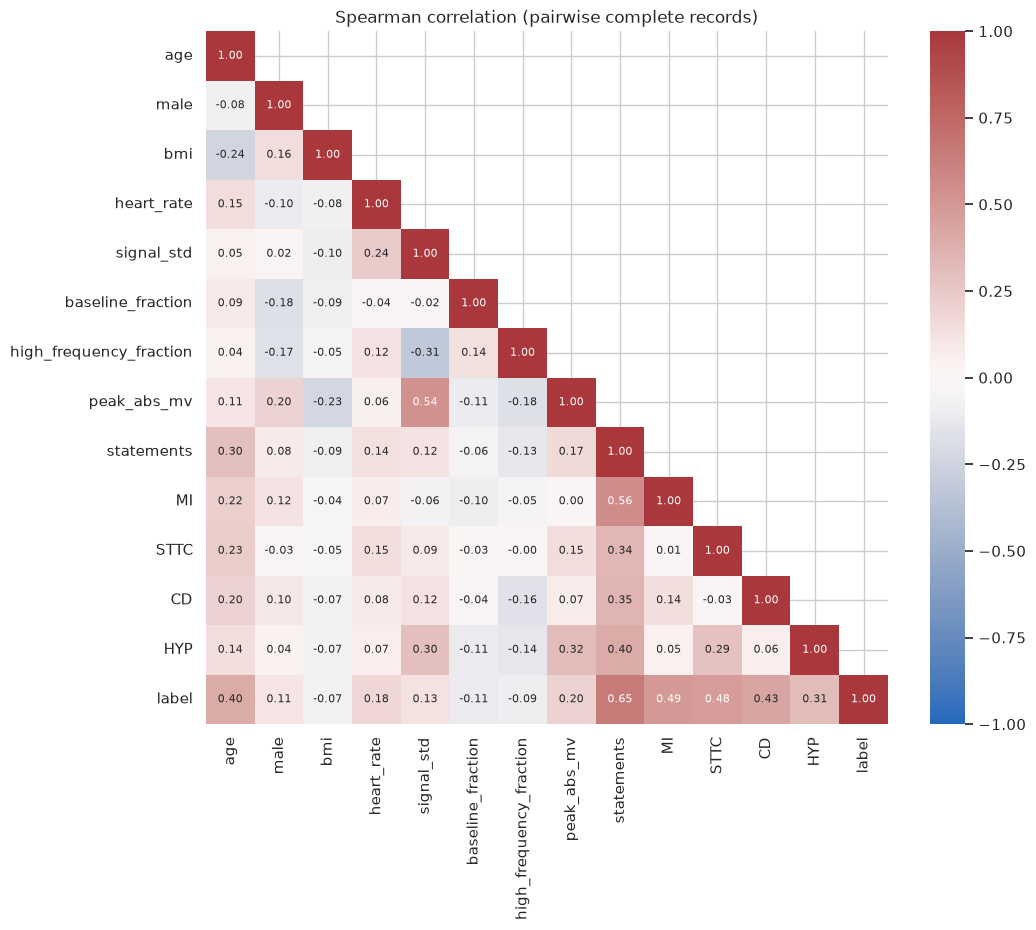

,spearman,pearson
statements,0.650,0.545
MI,0.494,0.494
STTC,0.478,0.478
CD,0.432,0.432
age,0.401,0.409
HYP,0.313,0.313
peak_abs_mv,0.202,0.159
heart_rate,0.181,0.207
signal_std,0.126,0.165
male,0.112,0.112


In [24]:
numeric = ["age", "male", "bmi", "heart_rate", "signal_std", "baseline_fraction", "high_frequency_fraction",
           "peak_abs_mv", "statements", "MI", "STTC", "CD", "HYP", "label"]
spearman = clean[numeric].astype(float).corr(method="spearman")
pearson = clean[numeric].astype(float).corr(method="pearson")
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(spearman, mask=np.triu(np.ones_like(spearman, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap="vlag", center=0, vmin=-1, vmax=1, annot_kws={"size": 8}, ax=ax)
ax.set(title="Spearman correlation (pairwise complete records)")
plt.show()
with_target = pd.DataFrame({"spearman": spearman["label"], "pearson": pearson["label"]}).drop("label")
display(with_target.sort_values("spearman", key=abs, ascending=False).round(3))

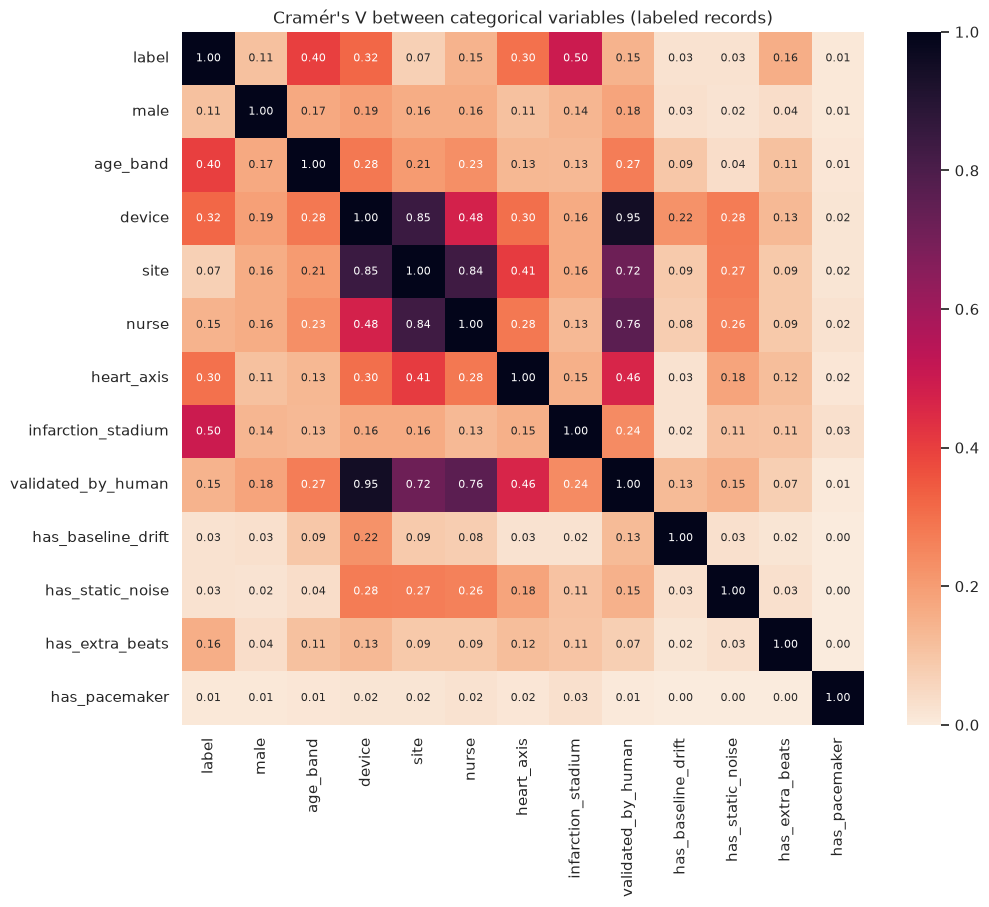

,Cramér's V with label
infarction_stadium,0.500
age_band,0.399
device,0.319
heart_axis,0.300
has_extra_beats,0.157
validated_by_human,0.148
nurse,0.148
male,0.112
site,0.071
has_baseline_drift,0.027


In [25]:
nominal = ["label", "male", "age_band", "device", "site", "nurse", "heart_axis", "infarction_stadium",
           "validated_by_human", "has_baseline_drift", "has_static_noise", "has_extra_beats", "has_pacemaker"]
labeled_clean = clean.dropna(subset=["label"])
association = cramers_v_matrix(labeled_clean, nominal)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(association, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1, annot_kws={"size": 8}, ax=ax)
ax.set(title="Cramér's V between categorical variables (labeled records)")
plt.show()
display(association["label"].drop("label").sort_values(ascending=False).round(3).to_frame("Cramér's V with label"))

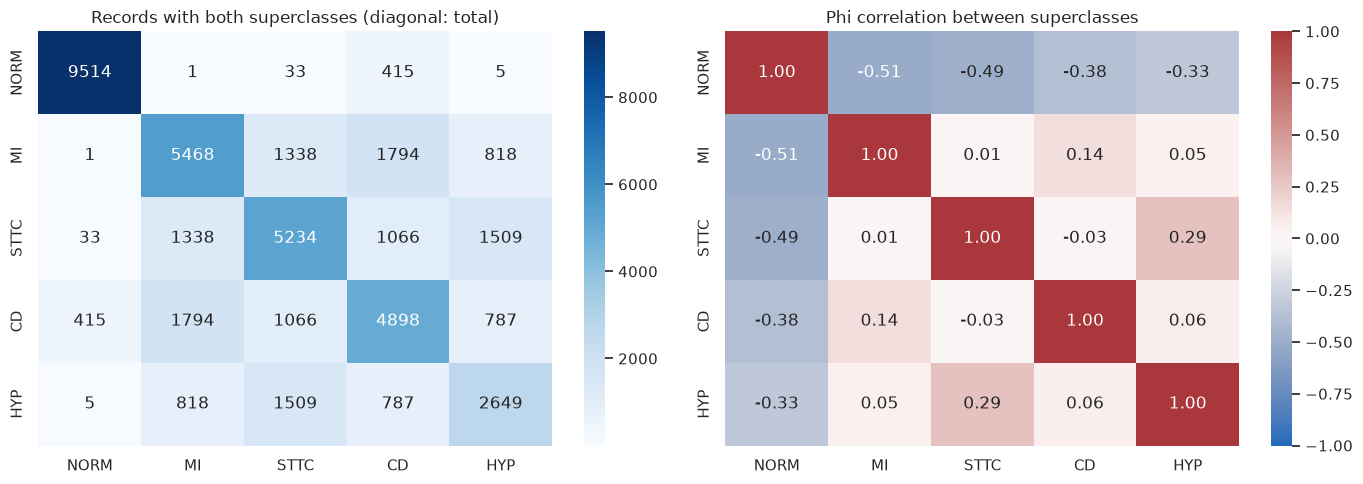

In [26]:
flags = clean[SUPERCLASSES].astype(int)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(flags.T @ flags, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set(title="Records with both superclasses (diagonal: total)")
sns.heatmap(flags.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set(title="Phi correlation between superclasses")
plt.tight_layout()
plt.show()

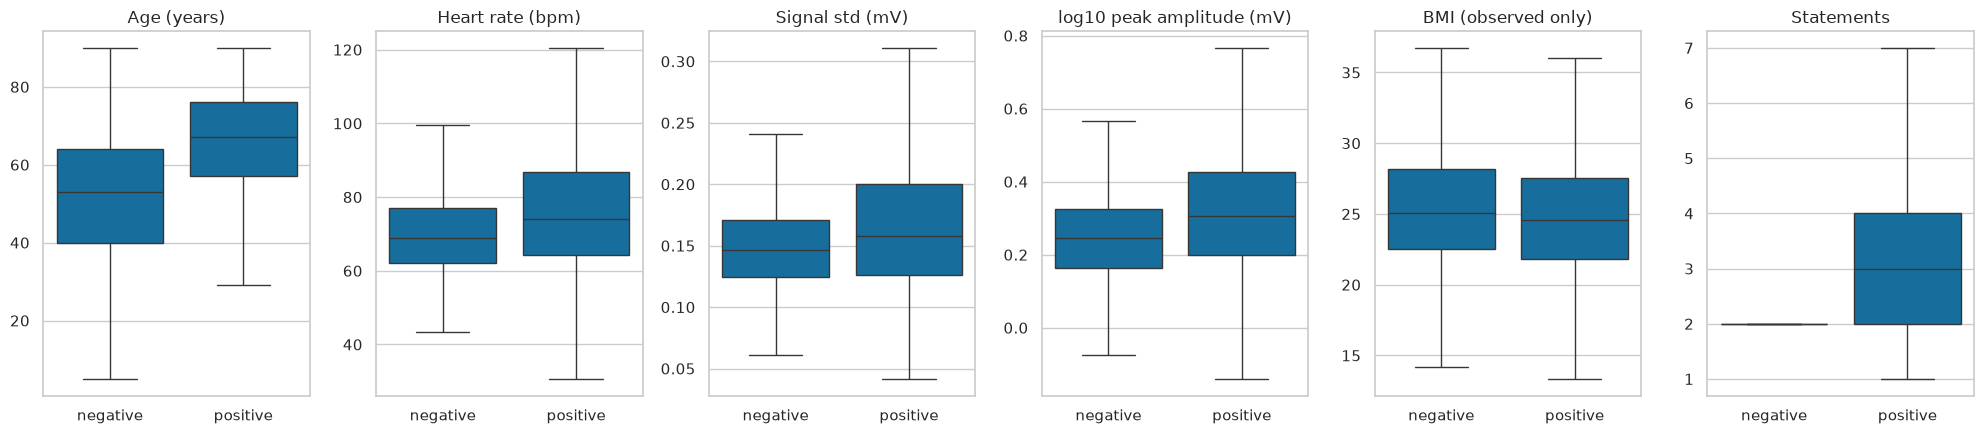

,median negative,median positive,Mann-Whitney p
variable,,,
age,53.000,67.000,0.0e+00
heart_rate,68.807,74.074,0.0e+00
signal_std,0.146,0.158,0.0e+00
log_peak,0.245,0.306,0.0e+00
bmi,25.102,24.558,0.0e+00
statements,2.000,3.000,0.0e+00


In [27]:
shown = labeled_clean.assign(target=labeled_clean["label"].map({1.0: "positive", 0.0: "negative"}),
                             log_peak=np.log10(labeled_clean["peak_abs_mv"]))
compared = {"age": "Age (years)", "heart_rate": "Heart rate (bpm)", "signal_std": "Signal std (mV)",
            "log_peak": "log10 peak amplitude (mV)", "bmi": "BMI (observed only)", "statements": "Statements"}
fig, axes = plt.subplots(1, 6, figsize=(20, 4.5))
for axis, (column, title) in zip(axes, compared.items()):
    sns.boxplot(shown, x="target", y=column, order=["negative", "positive"], showfliers=False, ax=axis)
    axis.set(title=title, xlabel="", ylabel="")
plt.tight_layout()
plt.show()
rows = []
for column in compared:
    negative = shown.loc[shown["target"] == "negative", column].dropna()
    positive = shown.loc[shown["target"] == "positive", column].dropna()
    rows.append({"variable": column, "median negative": negative.median(), "median positive": positive.median(),
                 "Mann-Whitney p": mannwhitneyu(negative, positive).pvalue})
tests = pd.DataFrame(rows).set_index("variable").round(3)
display(tests.assign(**{"Mann-Whitney p": tests["Mann-Whitney p"].map("{:.1e}".format)}))

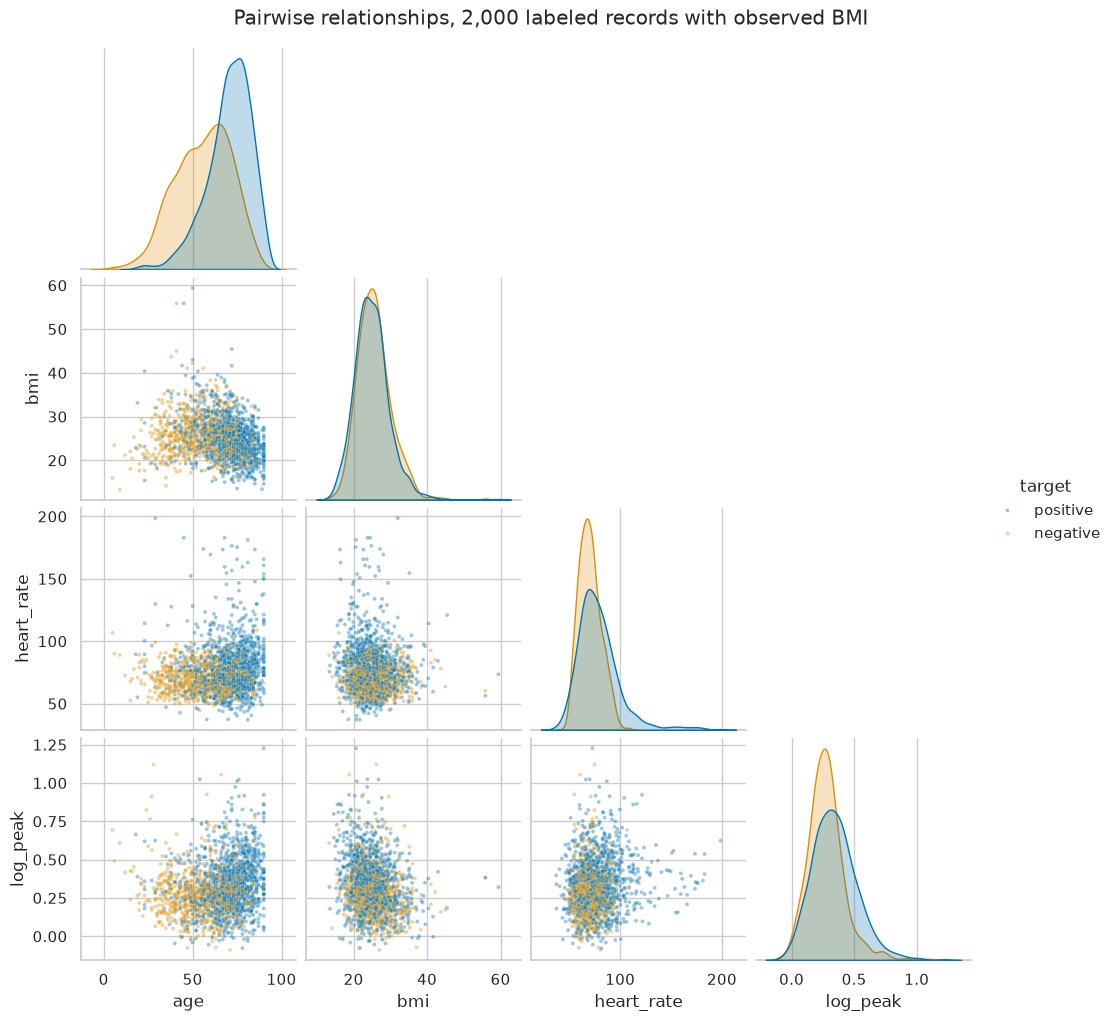

In [28]:
sample = shown.dropna(subset=["bmi"]).sample(2000, random_state=0)
grid = sns.pairplot(sample, vars=["age", "bmi", "heart_rate", "log_peak"], hue="target", corner=True,
                    plot_kws={"s": 8, "alpha": 0.4}, diag_kws={"common_norm": False})
grid.figure.suptitle("Pairwise relationships, 2,000 labeled records with observed BMI", y=1.02)
plt.show()

**Finding.**

- **Target and numeric variables.** Age has the strongest correlation with the label (Spearman 0.40). The
  waveform measures follow: largest sample 0.20, heart rate 0.18, signal standard deviation 0.13. Sex is
  weak (0.11), and BMI is almost unrelated (-0.07). Pearson gives the same ranking.
- **Correlations that are part of the definition.** The statement count (0.65) and the superclass flags
  (0.31-0.49) correlate with the label because the label is built from them. They are leakage, not
  predictors. The same holds for the infarction stage among the categorical variables (Cramér's V 0.50),
  which only exists when there is an infarction.
- **A confounder.** The noise measures correlate slightly negatively with the label (-0.11 and -0.09).
  Noise does not make an ECG normal. The likely cause is the device: `CS-12 E` has the lowest abnormal
  share (23%) and normal baseline power, while `CS100 3` filters out baseline power and has a 68% abnormal
  share (section 12). The device itself is associated with the label (V = 0.32), almost as strongly as
  age band (0.40).
- **Redundant variables.** Device, site, nurse and human validation are strongly associated with each
  other (device-validation V = 0.95, device-site 0.85, site-nurse 0.84). They describe the same thing,
  the ward and the period, so one of them is enough.
- **Among the waveform measures**, the signal standard deviation and the largest sample move together
  (0.54), and both are higher with hypertrophy (0.30 and 0.32 with HYP), as voltage criteria predict.
- **Superclasses.** NORM excludes the others (phi -0.33 to -0.51), apart from 415 records that are NORM
  and CD at once. MI often comes with CD (1,794 records), and STTC with HYP (1,509, phi 0.29).
- **Per class.** Positive records are older (median 67 against 53), have a faster heart rate (74 against
  69 bpm) and larger amplitudes. The BMI difference is statistically significant but tiny (24.6 against
  25.1): with thousands of records, a small p-value does not mean a large effect. In the pair plot, age is
  the only variable that separates the classes visibly; the others overlap heavily.

**Diagnoses, age and sex.**

How strongly does having a heart problem depend on age and sex? We show the share of records with
each superclass per age band (with 95% intervals), test the association, and fit a logistic
regression per superclass with age (per 10 years) and sex together.

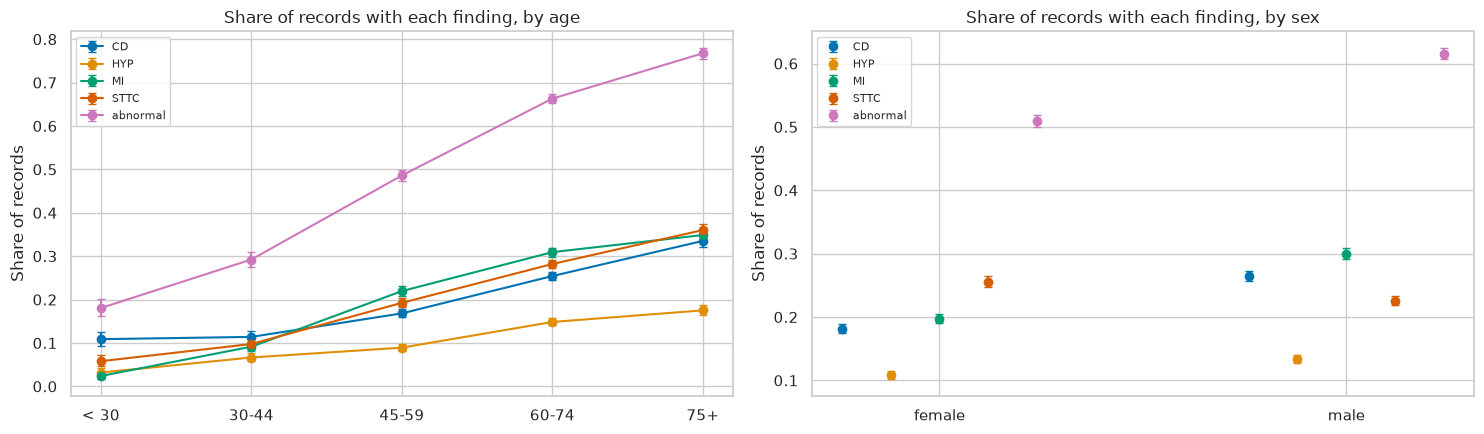

outcome,abnormal,MI,STTC,CD,HYP
age_band,,,,,
< 30,0.181,0.024,0.058,0.109,0.032
30-44,0.292,0.091,0.098,0.114,0.067
45-59,0.486,0.220,0.193,0.168,0.089
60-74,0.663,0.309,0.282,0.254,0.148
75+,0.768,0.349,0.360,0.335,0.175


Chi-square test, abnormal vs age band: p = 0.0e+00


In [29]:
outcomes = ["abnormal", "MI", "STTC", "CD", "HYP"]
by_age = prevalence(meta.dropna(subset=["age_band"]), "age_band", outcomes)
by_sex = prevalence(meta, "sex_name", outcomes)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_prevalence(by_age, "age_band", axes[0], "Share of records with each finding, by age")
plot_prevalence(by_sex, "sex_name", axes[1], "Share of records with each finding, by sex", connect=False)
plt.tight_layout()
plt.show()
display(by_age.pivot(index="age_band", columns="outcome", values="prevalence")[outcomes].round(3))
p_value = association_test(meta.dropna(subset=["age_band"]), "age_band", "abnormal")
print(f"Chi-square test, abnormal vs age band: p = {p_value:.1e}")

In [30]:
ratios = odds_ratios(meta.assign(age=meta["age_capped"]), outcomes)
display(ratios.round(3))

,outcome,predictor,odds_ratio,lower,upper,p_value
0,abnormal,age per 10 years,1.668,1.635,1.701,0.000
1,abnormal,male,1.849,1.743,1.962,0.000
2,MI,age per 10 years,1.494,1.460,1.528,0.000
3,MI,male,2.050,1.918,2.191,0.000
4,STTC,age per 10 years,1.437,1.406,1.470,0.000
5,STTC,male,0.941,0.882,1.004,0.067
6,CD,age per 10 years,1.377,1.346,1.408,0.000
7,CD,male,1.839,1.718,1.968,0.000
8,HYP,age per 10 years,1.358,1.320,1.398,0.000
9,HYP,male,1.408,1.294,1.533,0.000


In [31]:
adults = meta[meta["age_capped"] >= 18].copy()
adults["bmi"] = adults["weight"] / (adults["height"] / 100) ** 2
plausible = adults[(adults["bmi"] > 12) & (adults["bmi"] < 70)]
display(plausible.groupby("abnormal")["bmi"].describe().round(1).rename(
    index={False: "no abnormal superclass", True: "abnormal superclass"}))
repeats = meta.groupby("patient_id")["abnormal"].agg(["size", "nunique"])
repeaters = repeats[repeats["size"] > 1]
print(f"Patients with repeat ECGs whose abnormal status changes between ECGs: "
      f"{(repeaters['nunique'] > 1).sum()} of {len(repeaters)}")

,count,mean,std,min,25%,50%,75%,max
abnormal,,,,,,,,
no abnormal superclass,2960.0,25.6,4.5,13.4,22.5,25.1,28.1,58.8
abnormal superclass,3592.0,25.1,4.6,13.3,22.0,24.7,27.7,59.4


Patients with repeat ECGs whose abnormal status changes between ECGs: 417 of 2111


**Finding: age is the strongest driver, and sex matters for most findings.**

- The share of records with any abnormal superclass climbs steadily from 18% under 30 to 77% at 75 and
  over. The association is overwhelming (chi-square p effectively 0). Each additional 10 years
  multiplies the odds of an abnormal ECG by about 1.67.
- Men have about 1.85 times the odds of an abnormal ECG at the same age. The difference is largest for
  **myocardial infarction** (odds ratio about 2.0) and **conduction disturbances** (about 1.8).
  **ST/T changes are the exception**: they are not more common in men (odds ratio 0.94, p = 0.07).
  In the raw shares they are even slightly more common in women, because the women are older.
- Body mass index is essentially the same with and without an abnormal finding (median about 25).
- 417 of 2,111 patients with several ECGs change between normal and abnormal across recordings, so
  "patient" and "ECG" labels are not interchangeable.

These are associations in a hospital cohort, not risk estimates for the general population.

## 11. Signal integrity

For every one of the 21,799 records, `ecg_experiment/eda/signals.py` computes per-lead statistics from the raw 500 Hz
file (about 90 seconds on 6 cores, then cached):

- **shape and NaNs**: every record should be 5,000 x 12 with no missing samples;
- **flat leads**: a run of identical samples of at least 1 s, or a fully constant lead;
- **amplitude**: any sample above 10 mV (a normal QRS is 0.5-3 mV);
- **limb-lead identities**: the six limb leads come from three electrodes, so III = II - I,
  aVR = -(I + II)/2, aVL = (I - III)/2 and aVF = (II + III)/2 must hold. A violation above 0.05 mV means
  a lead is swapped, mislabeled, clipped or corrupted.

In [32]:
display(problem_counts(summary).to_frame("records"))
limb = summary[["einthoven_residual", "avf_residual", "avl_residual", "avr_residual"]].max(axis=1)
problems = summary[(summary["constant_leads"] > 0) | (summary["flat_leads"] > 0) | (limb > 0.05)]
display(problems[["constant_leads", "flat_leads", "peak_abs_mv", "einthoven_residual", "device"]]
        .sort_values("peak_abs_mv", ascending=False))

,records
records,21799
any_nan,0
fully_constant_lead,1
lead_flat_for_1s,2
lead_over_10mv,47
limb_identity_violated,7
heart_rate_not_estimated,0


,constant_leads,flat_leads,peak_abs_mv,einthoven_residual,device
record_id,,,,,
10565,0,0,32.716,32.753,CS100 3
21171,0,0,16.760,0.001,CS100 3
9129,0,0,9.937,0.001,CS100 3
15867,0,0,4.240,0.767,AT-6 C
9932,0,0,4.229,0.099,AT-6 C
12722,1,3,3.611,0.001,AT-6 6
5930,0,0,2.725,0.004,AT-6 C
162,0,0,2.585,0.002,AT-6 C
19299,0,2,2.152,0.001,CS-12


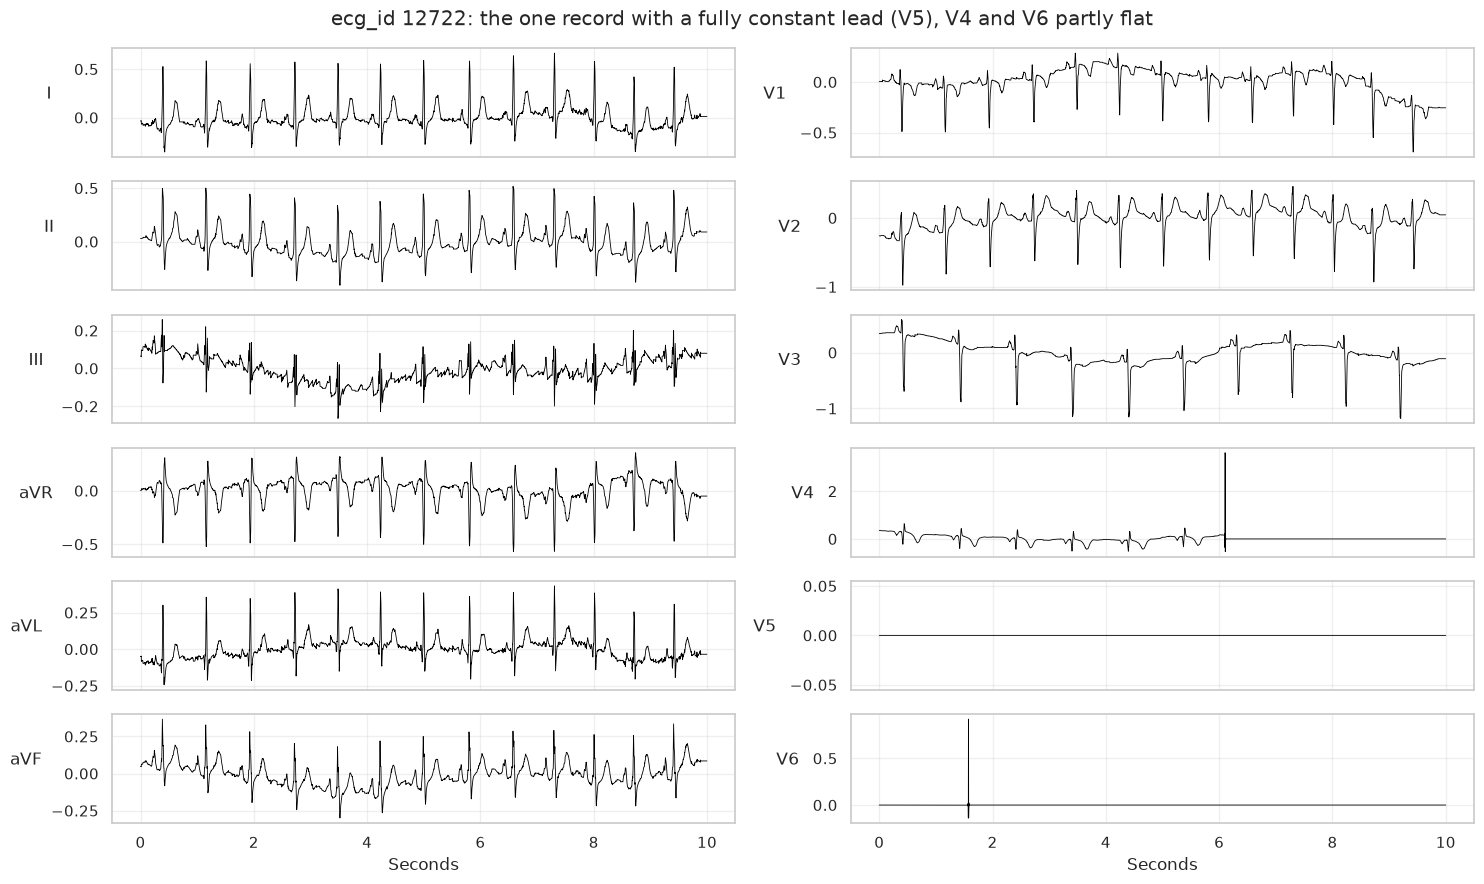

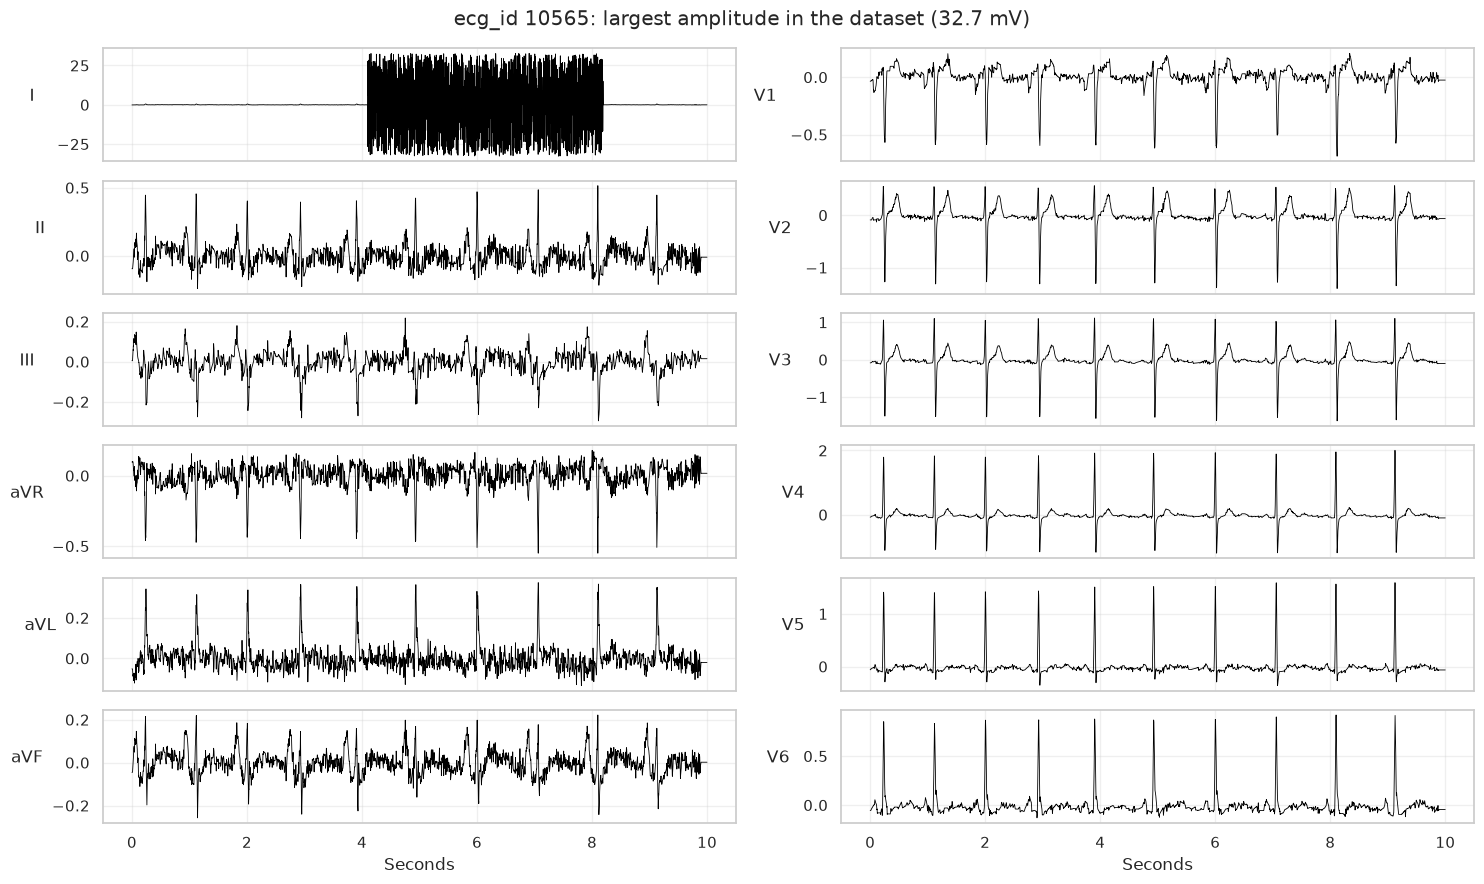

In [33]:
signal, fs = read_signal(meta.loc[12722, "filename_hr"])
plot_ecg(signal, fs, "ecg_id 12722: the one record with a fully constant lead (V5), V4 and V6 partly flat")
plt.show()
spike_id = summary["peak_abs_mv"].idxmax()
signal, fs = read_signal(meta.loc[spike_id, "filename_hr"])
peak = summary.loc[spike_id, "peak_abs_mv"]
plot_ecg(signal, fs, f"ecg_id {spike_id}: largest amplitude in the dataset ({peak:.1f} mV)")
plt.show()

**Finding: the waveforms are very clean.** Every record has exactly 5,000 samples and no NaNs. The
limb-lead identities hold to rounding (0.001 mV) in all but 7 records, so no leads are swapped
anywhere. One record (`ecg_id 12722`) has a fully constant V5, with V4 and V6 also largely flat; it
should not be used. 47 records contain short artifact spikes above 10 mV (up to 33 mV), spread across
all diagnoses; they are artifacts on otherwise usable records.

## 12. Signal distributions

Are amplitudes plausible per lead, do the noise measures mean something, do devices differ, and how
does heart rate vary with the diagnosis?

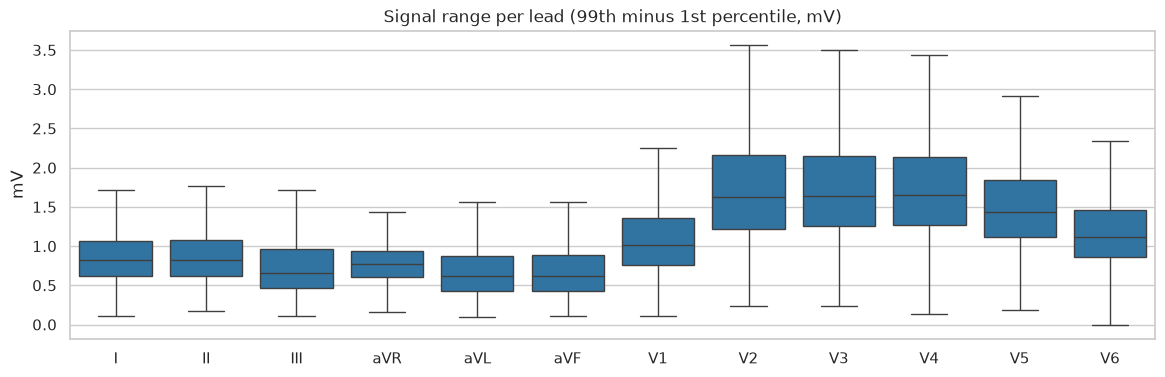

,annotation,annotated,records,baseline_fraction,high_frequency_fraction,powerline_50_fraction
0,baseline_drift,True,1598,0.065,0.006,7.000e-04
1,baseline_drift,False,20201,0.018,0.007,7.000e-04
2,static_noise,True,3260,0.011,0.009,1.000e-03
3,static_noise,False,18539,0.022,0.006,7.000e-04
4,burst_noise,True,613,0.010,0.007,7.000e-04
5,burst_noise,False,21186,0.020,0.007,7.000e-04
6,electrodes_problems,True,30,0.040,0.007,7.000e-04
7,electrodes_problems,False,21769,0.020,0.007,7.000e-04


In [34]:
leads = lead_features(meta)
leads["range_mv"] = leads["p99"] - leads["p01"]
fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(leads, x="lead", y="range_mv", order=LEADS, showfliers=False, ax=ax, color="tab:blue")
ax.set(title="Signal range per lead (99th minus 1st percentile, mV)", xlabel="", ylabel="mV")
plt.show()
display(annotation_agreement(summary))

**Finding.** Amplitudes follow textbook physiology: the precordial leads V2-V5 have the largest range
(about 1.5 mV) and aVL and aVF the smallest, so the units are genuinely mV. The noise measures agree
with PTB-XL's own human annotations. Records annotated with baseline drift have 3.6x more power below
0.7 Hz (0.065 vs 0.018), and records annotated with static noise have more power above 40 Hz. We can
therefore trust these measures to compare devices here and datasets later.

,records,abnormal_share,baseline_fraction,high_frequency,signal_std
device,,,,,
AT-60 3,966,0.586,0.003,0.007,0.135
CS100 3,6140,0.681,0.003,0.006,0.146
AT-6 C,514,0.722,0.030,0.006,0.166
CS-12 E,2878,0.232,0.032,0.007,0.156
CS-12,4048,0.606,0.033,0.008,0.144
AT-6 C 5.5,3950,0.546,0.039,0.007,0.162
AT-6 C 5.0,80,0.675,0.040,0.006,0.167
AT-6 6,2273,0.577,0.042,0.007,0.163
AT-6 C 5.3,67,0.493,0.044,0.009,0.163


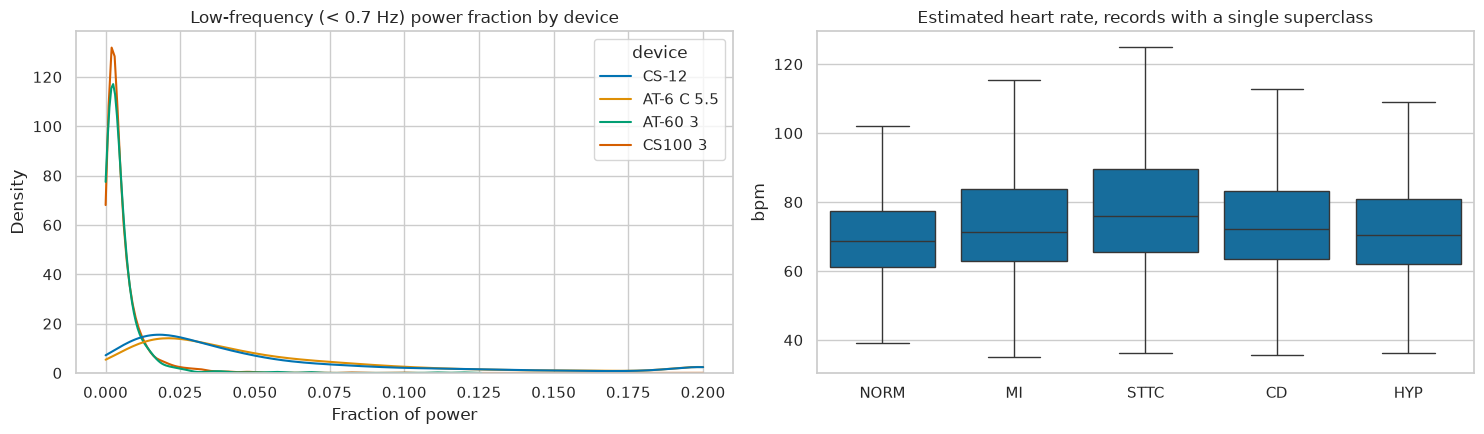

,count,mean,std,min,25%,50%,75%,max
classes,,,,,,,,
CD,1708.0,75.3,18.5,27.3,63.4,72.3,83.3,179.6
HYP,535.0,73.1,16.4,36.1,62.1,70.6,81.0,157.9
MI,2532.0,74.9,17.7,34.9,62.9,71.4,83.9,182.9
NORM,9069.0,70.3,13.2,35.8,61.2,68.6,77.5,151.5
STTC,2400.0,79.9,21.1,36.4,65.6,76.0,89.6,198.7


In [35]:
by_device = summary.groupby("device").agg(
    records=("std", "size"), abnormal_share=("abnormal", "mean"),
    baseline_fraction=("baseline_fraction", "median"), high_frequency=("high_frequency_fraction", "median"),
    signal_std=("std", "median"))
display(by_device.round(3).sort_values("baseline_fraction"))
shown = summary[summary["device"].isin(["CS100    3", "AT-60    3", "CS-12", "AT-6 C 5.5"])].copy()
shown["device"] = shown["device"].str.split().str.join(" ")
shown["baseline_fraction"] = shown["baseline_fraction"].clip(upper=0.2)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.kdeplot(shown, x="baseline_fraction", hue="device", common_norm=False, clip=(0, 0.2), ax=axes[0])
axes[0].set(title="Low-frequency (< 0.7 Hz) power fraction by device", xlabel="Fraction of power")
single = summary[summary["classes"].isin(SUPERCLASSES)]
sns.boxplot(single, x="classes", y="heart_rate", order=SUPERCLASSES, showfliers=False, ax=axes[1])
axes[1].set(title="Estimated heart rate, records with a single superclass", xlabel="", ylabel="bpm")
plt.tight_layout()
plt.show()
display(single.groupby("classes")["heart_rate"].describe().round(1))

**Finding: devices leave a fingerprint, and heart rate differs by diagnosis.**

- Two devices (`CS100 3` and `AT-60 3`) have about **10x less low-frequency power** than all the others
  (median 0.003 against 0.03-0.05). They almost certainly apply an internal high-pass filter. Devices
  also differ in their share of abnormal records (from 23% to 72%), because different wards
  used different machines. Device and diagnosis are therefore entangled in this dataset.
- NORM records have the lowest and narrowest heart-rate distribution (median about 69 bpm); STTC has the
  highest median. The heart rate is our own estimate from QRS detection; the MIMIC notebook validates it
  against machine-measured RR intervals.

## 13. Looking at the signals, and normalizing them for display

One randomly chosen record from each diagnostic superclass.

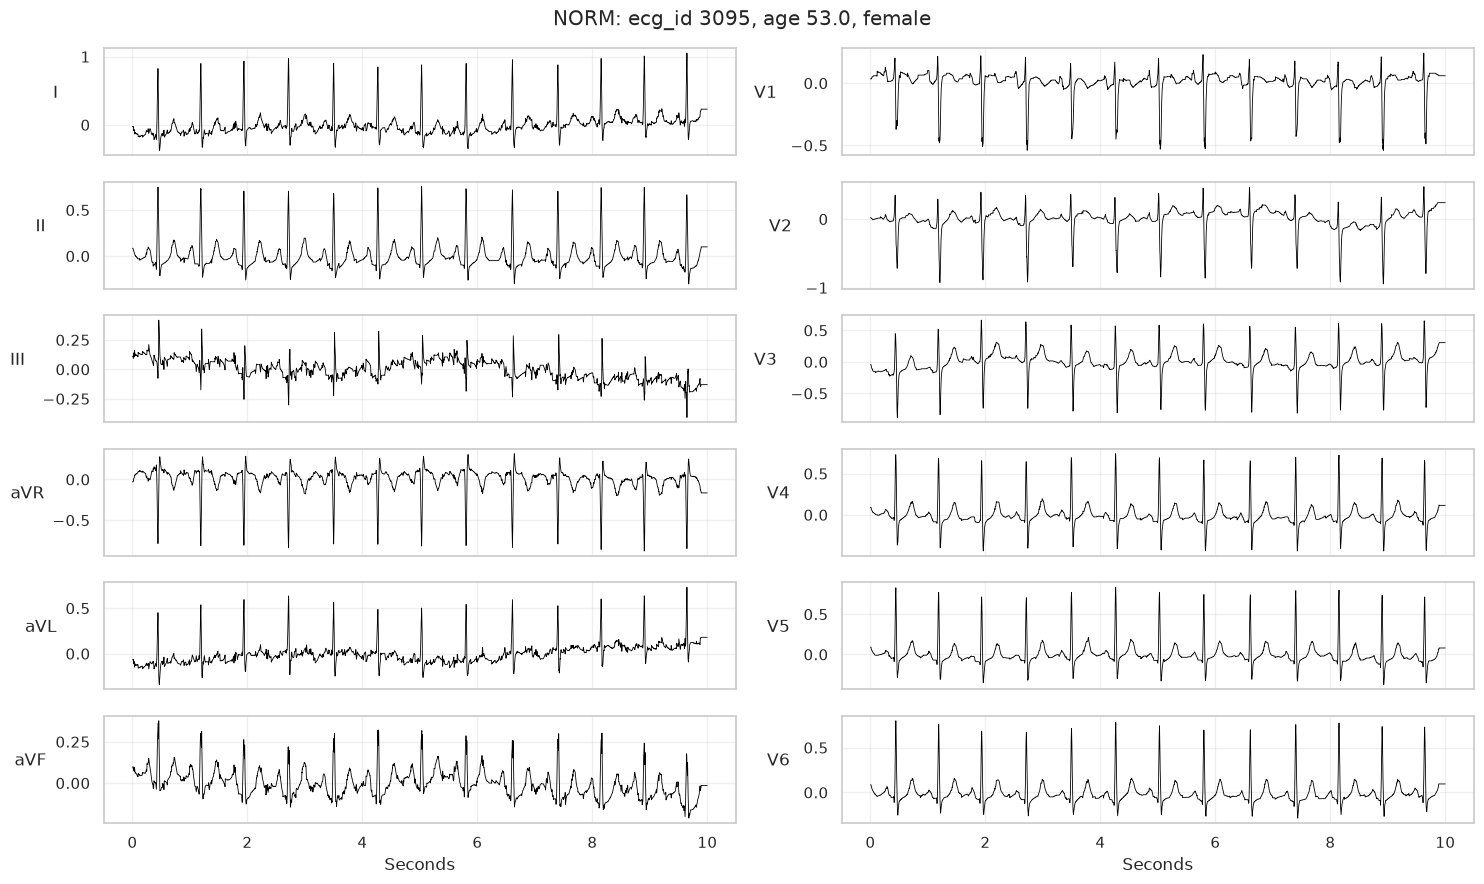

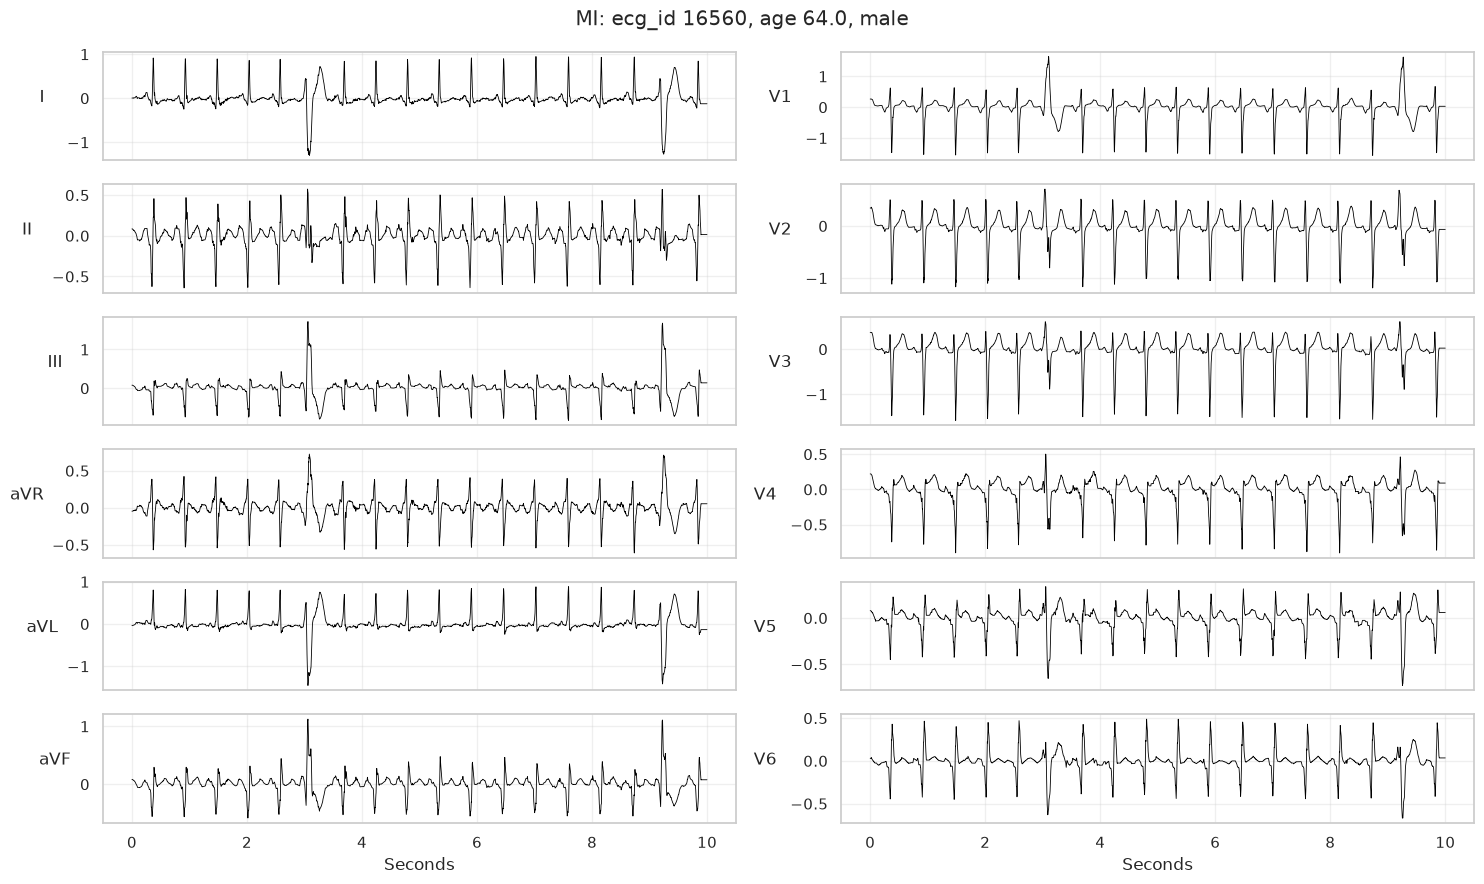

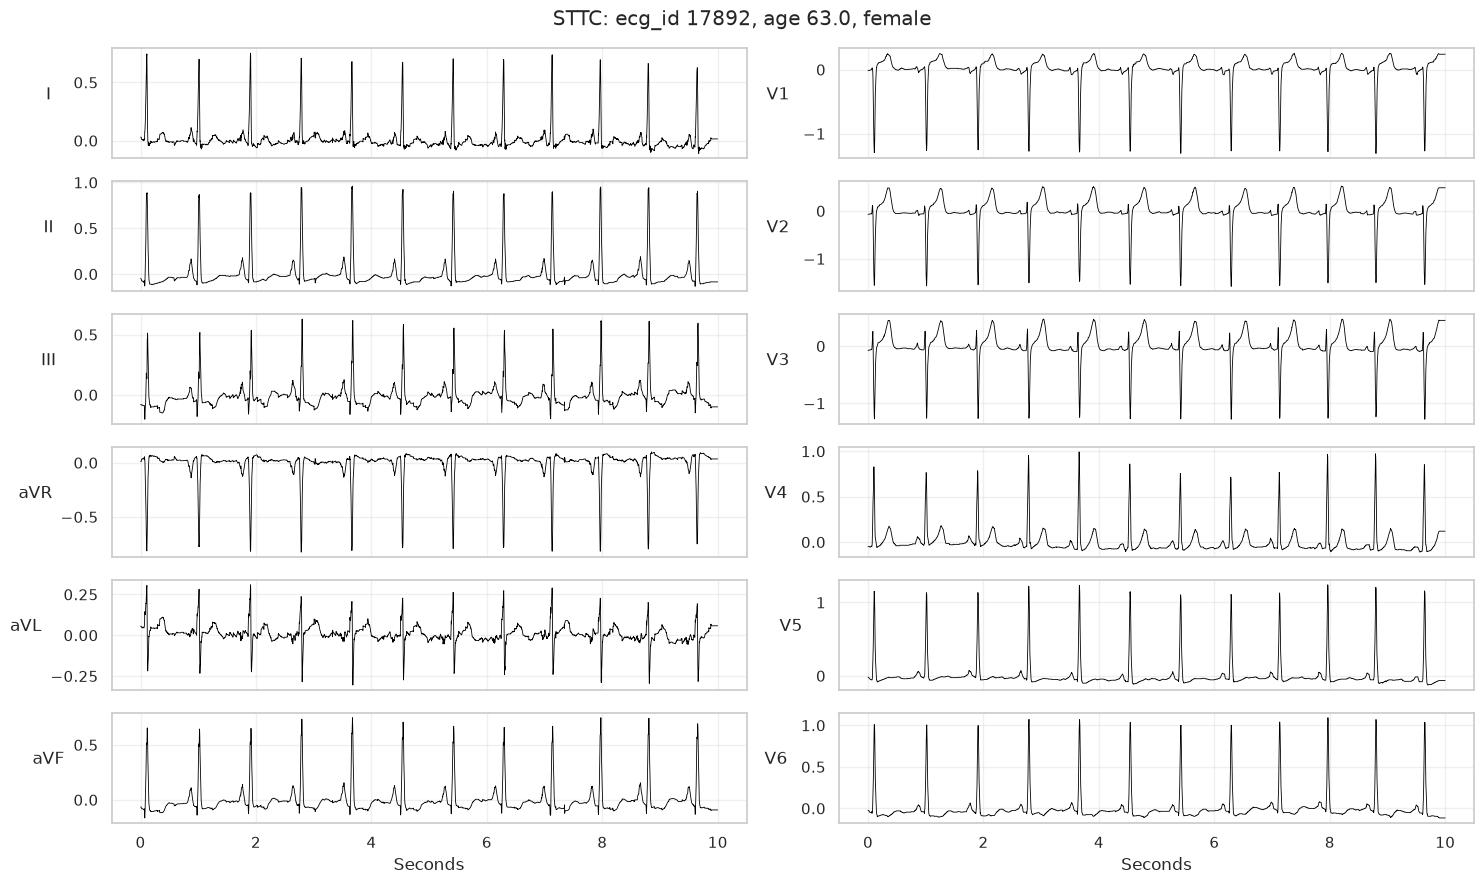

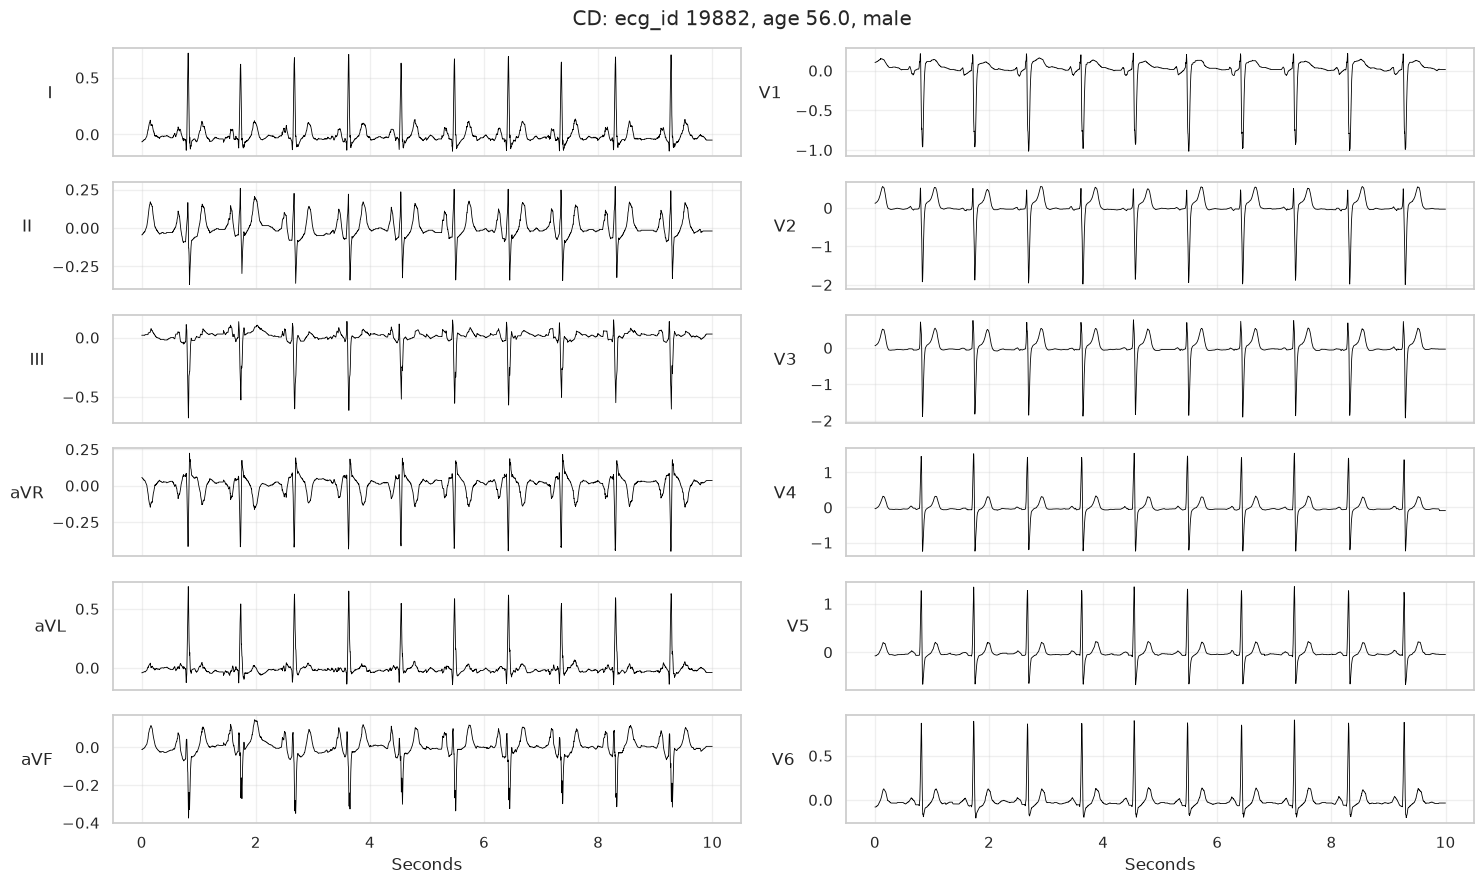

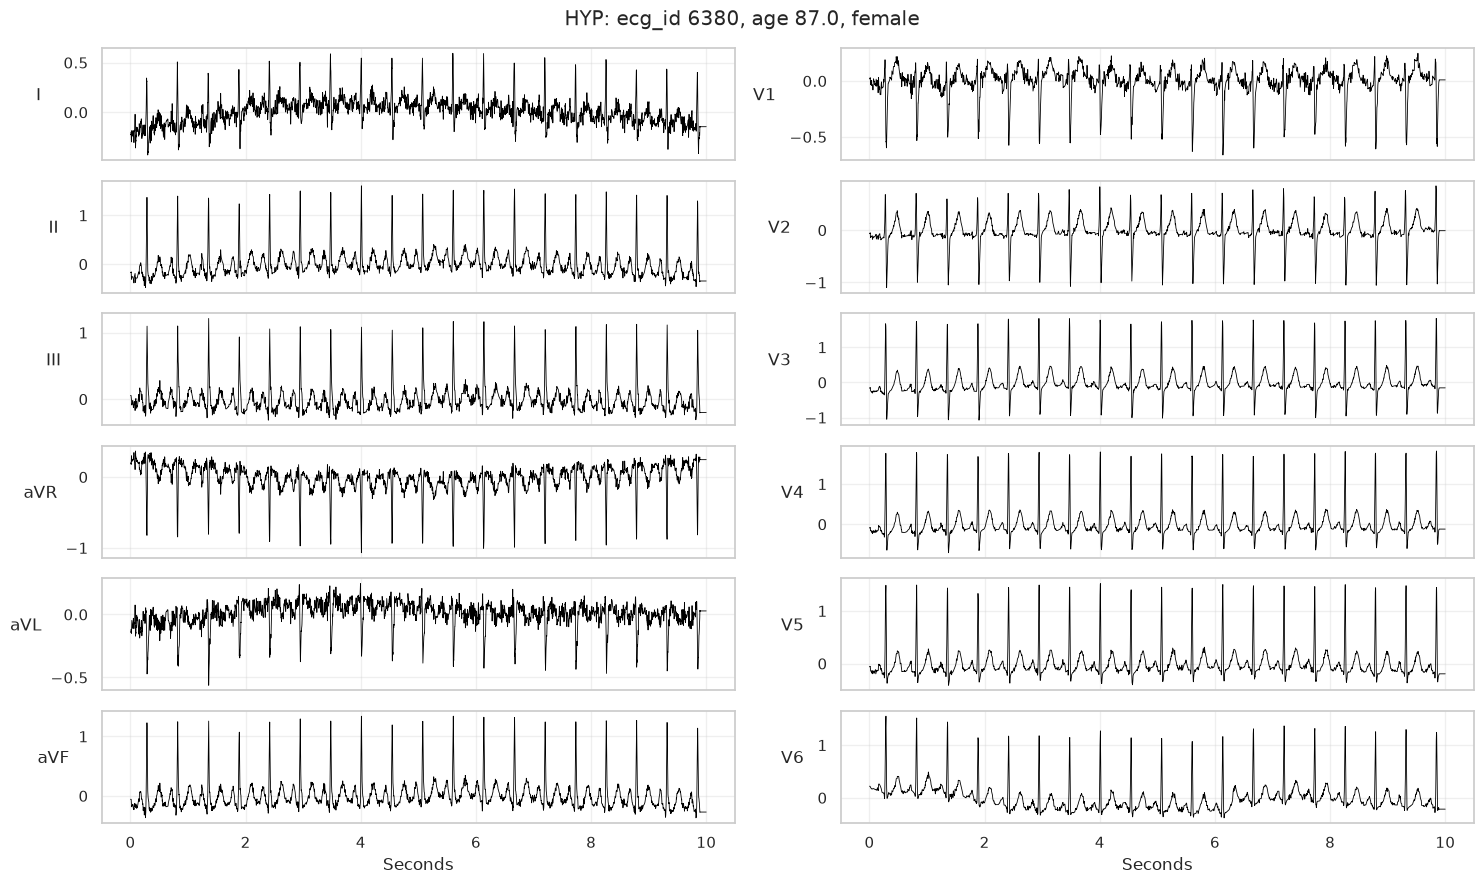

In [36]:
for group in ["NORM", "MI", "STTC", "CD", "HYP"]:
    row = meta[meta["classes"] == group].sample(1, random_state=0).iloc[0]
    signal, fs = read_signal(row["filename_hr"])
    plot_ecg(signal, fs, f"{group}: ecg_id {row.name}, age {row['age']}, {row['sex_name']}")
    plt.show()

**Finding.** The records look like standard clinical twelve-lead ECGs, with leads in the right place
(lead I and V5-V6 upright in normal sinus rhythm, aVR negative) and visible morphology changes in the
abnormal examples.

**Should the signals be normalized to view them better?** ECGs are not images, but the same question
applies to plotting them. Below, one record with strong baseline wander (99th percentile of low-frequency
power) is shown raw, after a 0.5 Hz high-pass filter, and after additionally scaling each lead to unit
variance.

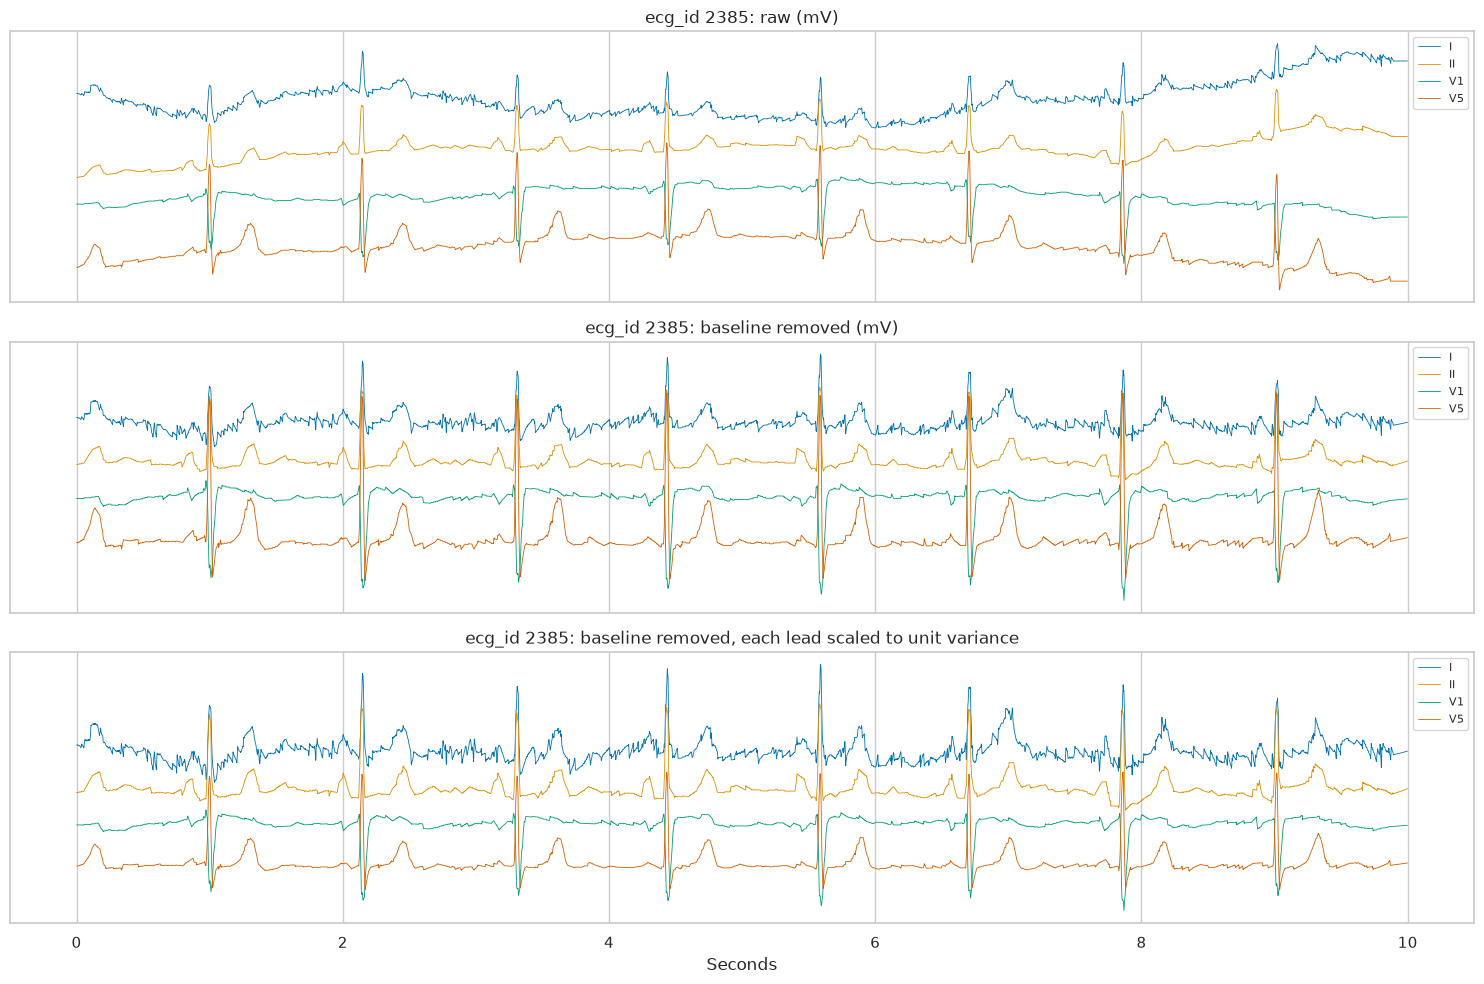

,signal_std,peak_abs_mv
classes,,
NORM,0.147,1.780
MI,0.134,1.750
STTC,0.146,1.878
CD,0.167,2.029
HYP,0.198,2.760


In [37]:
candidates = clean.loc[~clean["spike_over_10mv"], "baseline_fraction"]
wander_id = (candidates - candidates.quantile(0.99)).abs().idxmin()
signal, fs = read_signal(meta.loc[wander_id, "filename_hr"])
filtered = remove_baseline(signal, fs)
versions = {"raw (mV)": signal, "baseline removed (mV)": filtered,
            "baseline removed, each lead scaled to unit variance": standardize_leads(filtered)}
time = np.arange(len(signal)) / fs
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for axis, (name, version) in zip(axes, versions.items()):
    step = 3 * np.median(version.std(axis=0))
    for offset, lead in enumerate(["I", "II", "V1", "V5"]):
        axis.plot(time, version[:, LEADS.index(lead)] - offset * step, linewidth=0.6, label=lead)
    axis.set(title=f"ecg_id {wander_id}: {name}", yticks=[])
    axis.legend(fontsize=8, loc="upper right")
axes[-1].set(xlabel="Seconds")
plt.tight_layout()
plt.show()
single_class = clean[meta.loc[clean.index, "classes"].isin(SUPERCLASSES)]
display(single_class.groupby(meta.loc[single_class.index, "classes"])[["signal_std", "peak_abs_mv"]]
        .median().loc[SUPERCLASSES].round(3))

**Finding.** The high-pass filter fixes the problem that matters for display: it removes the wandering
baseline while keeping the signal in mV, so amplitudes remain comparable between leads and records.
Scaling each lead to unit variance makes every lead look equally large and erases the absolute voltage,
which carries diagnostic information: the median largest sample is 2.76 mV in hypertrophy against
1.78 mV in normal ECGs, and the signal standard deviation 0.198 against 0.147 mV. For viewing, the
signals should therefore get baseline removal and a fixed mV scale, not per-lead standardization.

## 14. The 100 Hz version of the release

PTB-XL ships every record twice, at 500 Hz and at 100 Hz. We check that the two agree.

In [38]:
consistency = low_rate_consistency(meta, records=300)
display(consistency.describe().round(4))

,correlation,max_abs_difference_mv,median_abs_difference_mv
count,300.000,300.000,3.000e+02
mean,0.990,0.661,2.000e-03
std,0.013,0.612,1.100e-03
min,0.892,0.105,8.000e-04
25%,0.991,0.257,1.300e-03
50%,0.994,0.400,1.700e-03
75%,0.996,0.868,2.400e-03
max,1.000,3.574,5.800e-03


**Finding.** The 100 Hz files are a smoothed version of the 500 Hz files. The typical sample differs by
only about 0.002 mV (correlation 0.99), but the sharpest point of each record, usually a QRS peak,
differs by a median of 0.4 mV (up to 3.6 mV at artifact spikes). A different anti-aliasing filter was
used. The 100 Hz version blunts QRS complexes slightly, which matters for measurements of QRS amplitude
or shape.

## 15. Answers to the guiding questions

**Are there missing values, and do they follow a pattern?** Yes. The core fields are complete. Height
(68%), weight (57%), validator (43%) and heart axis (39%) are often missing, and the noise and
infarction columns are mostly empty because they are only filled when something was noted. The gaps
follow the device and the period: AT-6 machines record height and weight, the CS machines record the
heart axis, and the switch happens in 1998 (sections 3 and 6).

**What are the summary statistics?** Records come from 18,869 patients; the median age is 61 (2 to 89,
plus 293 records over 89), 52% are men, the median height is 166 cm and the median weight 70 kg. The
median heart rate is 71 bpm, and a record carries a median of 2 statements (sections 1, 2 and 5).

**Are there outliers?** Yes, of two kinds. Data-entry errors in the metadata (heights down to 6 cm,
weights of 5 kg, age 300 as a placeholder) are corrected. In the signals, there is one dead lead and
there are 47 artifact spikes above 10 mV. Tukey flags 3-9% of the waveform measurements as unusual;
those values are kept because the rule alone does not establish that they are errors (sections 4, 5 and 11).

**What is the cardinality of the categorical variables?** Low for the true categories (2 to 12
classes). High for the report (9,887), the statement combinations (4,074), the noise columns (up to 317)
and the site (51). These are reduced to flags, superclasses and grouped categories (sections 2 and 9).

**Are distributions skewed, and is a non-linear transform needed?** Age is close to symmetric. Weight is
moderately right-skewed. The waveform measures are strongly right-skewed (skewness up to 11.9), and a
log10 comparison reduces their skewness (section 5). This is a display comparison, not evidence
that a model needs or benefits from the transform.

**Are there temporal trends?** Yes. The abnormal share rises from 45% in 1986 to 68% in 2000, human
validation falls after 1997, and the device mix changes in 1998 (section 6).

**Do the target and the other variables correlate?** Age is the strongest independent correlate of the
label (Spearman 0.40, Cramér's V 0.40 for age band), followed by device (0.32), amplitude and heart rate.
The statement count and infarction stage correlate more, but only because they are part of the label's
definition (section 10).

**How are the data distributed across categories?** Abnormal findings rise steadily with age (18% under
30, 77% at 75 and over). Men have higher odds of infarction and conduction disturbance, but not of ST/T
changes. Devices differ in case mix (23% to 72% abnormal) and in filtering (sections 10 and 12).

**Should the "images" be normalized to view them better?** The ECGs are signals, not images. For
display they need baseline-wander removal and a fixed mV scale. Per-lead standardization is not
advisable, because the absolute voltage differs by diagnosis (section 13).

**Is the target imbalanced?** Moderately: 62% of labeled records are positive, and 12% of all records are
unlabeled. Within the positives, hypertrophy is the rarest superclass (22%). The imbalance reverses in
young patients (section 8).

## 16. Conclusions

- **Structure.** 21,799 ten-second, twelve-lead ECGs from 18,869 patients, with 27 metadata columns, most
  of them categorical or free text. 2,111 patients have repeat recordings, and 417 of them change between
  normal and abnormal, so patient-level handling is essential.
- **Missing values.** Core fields are complete. Height, weight, validator and heart axis are often
  missing, and the pattern is set by the recording device and period, not by chance. Empty noise and
  infarction columns mean "not noted".
- **Wrong values.** Age 300 is a placeholder for over 89 (293 records). A handful of adult heights (as
  low as 6 cm) and weights (5 kg) are data-entry errors. Children's small values are real.
- **Distributions.** Age is near-symmetric; the waveform measures are strongly right-skewed and become
  less skewed in the log10 comparison. Statistical outlier flags identify values to inspect;
  they do not establish the cause of an unusual measurement.
- **Time.** The share of abnormal records rises over the years while the median age does not, and the
  recording system changes in 1998.
- **Target.** Among labeled records, 62% are positive. The odds of an abnormal ECG rise about 1.7x per
  decade of age and are about 1.85x higher in men. Infarction and conduction disturbances are the most
  male-dominated; ST/T changes are not associated with sex once age is accounted for.
- **Relationships.** Age is the main correlate of the label. Device, site, nurse and validation are
  nearly interchangeable and are associated with both the label and the signal filtering, so the device
  is a confounder. The statement count and infarction stage leak the label.
- **Preprocessing.** Placeholders, impossible values, informative gaps and high-cardinality text were
  handled explicitly, and one record with a dead lead was removed. The clean table has 21,798 records.
- **Signals.** Complete and clean: no NaNs, correct lead relationships, physiological amplitudes. One
  record has a dead lead, and 47 have artifact spikes. The 100 Hz release is slightly smoothed. For
  display, baseline removal on a fixed mV scale is better than per-lead standardization.

The next notebook describes MIMIC-IV-ECG, a much larger hospital dataset without cardiologist labels.